# Решение — предсказание дней занятости аренды


**Цель:** предсказать `target` — число дней занятости (или простоя) объекта аренды в году, диапазон **0–365**.
**Метрика:** MSE.
**Данные:** ~36.7k train / ~12.2k test, NYC Airbnb-подобные данные.
**Лучший результат на public LB:** `submission_v3n_nm_best.csv` — **8701.94**.

## Описание финального решения

### Как обработал данные

1. **Объединение train + test** через флаг `is_train` — единый pipeline для всех преобразований, без double-encoding и без leak'а через test-статистики.
2. **NaN-обработка**: `host_name` → `'__nan__'`, `name` → `''`, `avg_reviews` → 0.
3. **Парсинг дат**: `last_dt` → `last_dt_parsed` (datetime), отсюда `days_since_last_review`, `review_year`, `review_month`, флаг `has_reviews = last_dt.notna()`.
4. **Клиппинг выбросов**: `sum` ограничивается 99-м перцентилем; `min_days` — 365 (нефизичные значения > года).
5. **Log-трансформация** для всех скошенных числовых признаков: `sum`, `min_days`, `amt_reviews`, `avg_reviews`, `total_host`.
6. **Гео-обработка**: расстояния до центра NYC и Times Square, KMeans-кластеры с k=30 и k=50 на (lat, lon) (плюс `_freq` и `_dist` к центру кластера), плотности `density_{0.5/1/2}km` через BallTree haversine.
7. **Текстовые признаки из `name`**: длина, число слов, доля заглавных, дэши, восклицания, заглавные слова, плюс ~25 ключевых слов в трёх группах:
   - премиум-кейворды (`times_square`, `near`, `manhattan`, `queens`, `subway`, `central`, `midtown`, `village`);
   - бюджет-кейворды (`sunny`, `spacious`, `brooklyn`, `bedroom`, `cozy`, `small`, `shared`, `basic`);
   - общие (`private`, `room`, `apt`, `studio`, `entire`, `luxury`, `modern`, `beautiful`, `quiet`, `near`);
   - производные `kw_premium_count`, `kw_budget_count`, `kw_premium_ratio`, `name_has_number` (паттерн `Nbr/bed/bath/room`).
8. **Frequency-encoding** для `location`, `type_house`, `location_cluster`, `host_uid` (= `host_name + '_' + cluster`).
9. **Aggregations по `_id`**: `id_mean_sum`, `id_std_sum`, `id_mean_reviews`, `id_mean_min_days`, `id_n_locations`, `id_n_types`, `id_listing_count`, `id_freq`, `id_mean_vitality`, `id_rank`, `log_id`.
10. **Aggregations по multi-listing хостам** (только хосты с ≥2 объектами): `host_price_range` (max−min цены), `host_type_diversity` (число типов жилья).
11. **Группа «активность и живучесть листинга»**:
    - `recency_bucket` (4 = свежий < 30д, 3 = 30–180д, 2 = 180–365д, 1 = > 365д, 0 = нет отзывов);
    - `listing_vitality = has_reviews * max(365 − days_since, 0) / 365`;
    - `host_activity_score = log_amt_reviews * recency_bucket`;
    - `review_staleness = days_since / (listing_age_months * 30)`;
    - `listing_age_months = amt_reviews / avg_reviews` (косвенный возраст);
    - `first_review_days_ago = days_since + age_months * 30`.
12. **Группа «доходные/выручка»**:
    - `min_booking_value = sum * min_days` (+ log версия);
    - `host_revenue_proxy = sum * total_host` (+ log версия);
    - `annual_review_rate = avg_reviews * 12`;
    - `price_per_review = sum / (amt_reviews + 1)`;
    - `reviews_density = amt_reviews / listing_age_months`.
13. **Z-score и ранги**:
    - `price_zscore_location`, `price_vs_location_median`;
    - `sum_rank_in_location`, `sum_rank_in_type`, `reviews_rank_in_location`;
    - `min_days_bucket` (бины 0/1/3/7/14/30/90/365), `host_scale` (бины total_host: 0/1/5/20/50).
14. **Кросс-взаимодействия** (то, что не ловится сырой корреляцией):
    - `sum_x_type`, `min_days_x_type` (через `type_encoded` ∈ {1, 2, 2.5, 3});
    - `reviews_x_location_freq`;
    - `pro_host_x_min_days`, `pro_host_x_no_reviews`, `pro_host_x_high_price`;
    - `log_total_host_x_log_min_days`, `min_days_x_total_host`;
    - `shared_x_price`, `shared_low_price`.
15. **Бинарные «сигнальные» флаги**:
    - `no_reviews`, `few_reviews`, `high_price`, `long_min_days`, `very_long_min_days`, `old_or_no_review`, `is_shared`, `is_professional_host`;
    - агрегаты `dead_listing_score` и `dead_listing_v2`.
16. **Target encoding (3 типа, все через `GroupKFold` по `host_name`, без leak'а)**:
    - **Стандартный TE по `_id`** (leave-one-out): 12 статистик — `mean`, `median`, `std`, `min`, `max`, `q25`, `q75`, `IQR`, `range`, `count`, `zero_frac`, `high_frac`;
    - **TE по `geo_k30` и `geo_k50`**: `mean`, `zero_frac`, `high_frac`;
    - **TE по `location`**: `loc_te_mean`, `loc_te_high_frac`, `loc_te_zero_frac`;
    - **k-NN target encoding** по координатам с k ∈ {5, 10, 20} (BallTree haversine, mean + std → 6 фич);
    - **Cross-TE** по 4 парам: `location_cluster * type_house`, `location * type_house`, `geo_k50 * type_house`, `host_name * type_house`.

Итого **21 стандартная TE-фича + 6 k-NN + 4 cross-TE = 31 TE-признак**.

17. **Финальные матрицы**:
    - `X_train` (164 признака) — для CatBoost (с native categorical: `location_cluster`, `location`, `type_house`);
    - `X_train_le` — LabelEncoded для XGBoost / LightGBM;
    - `X_train_rf` — чистый numpy float для ExtraTrees / RandomForest.

### Какой алгоритм выбрал

**Многоуровневый стэкинг 10 моделей** через **Ridge meta-learner + Nelder-Mead оптимизацию весов**:

| # | Модель | Особенность | Seeds |
|---|---|---|---|
| 1 | CatBoostRegressor (raw target) | depth=8, native cat, RMSE, early stopping | 3 |
| 2 | XGBoostRegressor (raw) | hist, `enable_categorical=True`, depth=8 | 5 |
| 3 | LightGBM DART | drop_rate=0.1, skip_drop=0.5, depth=7 | 3 |
| 4 | CatBoost на `log1p(target)` | то же, что #1, но в log-пространстве | 3 |
| 5 | LightGBM на `log1p(target)` | depth=7 | 3 |
| 6 | LightGBM Quantile q50 | `objective='quantile'`, alpha=0.5 | 3 |
| 7 | LightGBM Quantile q70 | `objective='quantile'`, alpha=0.7 | 3 |
| 8 | Hurdle (zero-inflated) | LGBMClassifier(P(y=0)) & LGBMRegressor(y \| y>0) | 3 |
| 9 | ExtraTreesRegressor | 500 деревьев, max_features=0.7 | 3 |
| 10 | RandomForestRegressor | 500 деревьев, max_features=0.5 | 3 |

Всего обучается **32 модели * 5 фолдов = 160 fit'ов**

**Финальный ансамбль — двухступенчатый:**

1. **Ridge meta-stacking** с `positive=True` (все веса ≥ 0 — иначе одна модель «отнимает» у другой, что неустойчиво). Тестируется **7 разных комбинаций моделей** на OOF — по каждой считается CV MSE через GroupKFold, выбирается лучшая:
   - `all_10` (все 10), `no_quant` (без квантильных), `no_hurdle`, `core_8_v3m` (без ET/RF), `with_bagging`, `minimal`, `log_diverse`.
   - Лучшая комбинация по CV: **`log_diverse`** (CB_deep + CB_log + LGB_log + LGB_q50 + Hurdle + ET + RF), MSE = **8517.96**.

2. **Nelder-Mead** оптимизация выпуклой комбинации весов на той же лучшей подвыборке моделей: MSE = **~8513**.
   Лучшие NM-веса: `CB_deep ≈ 0.48, XGB ≈ 0.10, Hurdle ≈ 0.30, ET ≈ 0.10` (остальные ~0).

### Особенности при обучении

1. **Множественные seeds** — 5 для XGBoost (быстрый), 3 для всех остальных. Усредняем OOF и test по seeds → стабилизация.
2. **GroupKFold по `host_name`** для всех 10 моделей и для всех target encodings — единственный способ избежать leak'а через хоста.
3. **Early stopping** для CatBoost / XGBoost / LightGBM-eval (100 итераций без улучшения на eval_set).
4. **Native categorical features**: CatBoost получает `cat_features` напрямую, XGBoost — через `enable_categorical=True`, LightGBM — через `LabelEncoder` (3 cat-колонки).
5. **Log-зеркало**: для CB/LGBM дополнительно учим версию на `log1p(y)`, в инференсе делаем `expm1`. **Важный нюанс:** усреднение по фолдам делается **в log-пространстве**, и только потом `expm1` — это даёт геометрическое среднее (более устойчивое к выбросам), а не арифметическое. Лог-модели в одиночку слабее (MSE считается на raw scale), но в стэкинге дают самый большой прирост — корреляция с CB_deep всего 0.88–0.93.
6. **Hurdle-модель**: отдельный классификатор для `P(y=0)` и регрессор на ненулевой части → `pred = (1 − P_zero) * E[y | y > 0]`. Хорошо ловит большую долю нулей в распределении.
7. **Quantile-регрессоры (q50, q70)** — добавляют робастность, когда основная модель «съезжает» из-за тяжёлого хвоста.
8. **Bagging diversity (ET + RF)** — модели на других принципах деления (random splits + subsampling признаков) → корреляция с CatBoost ~0.98 (а не 0.99+, как у бустингов между собой).
9. **Post-blend host-mean**: на сабмишшене для рядов, у которых хост встречался в train **≥2 раза** (`mc=2`), делаем `0.3 * host_mean + 0.7 * pred` — добавляет ещё ~0.5–1.0 на LB. Для одноразовых хостов не применяется (шум перевешивает сигнал).
10. **Все предсказания клиппятся** в `[0, 365]` — физически осмысленный диапазон target.

### Как валидировал

- **GroupKFold(n_splits=5)** по `host_name` — единственный честный CV: один хост может иметь много объектов и в train, и в test. При обычном KFold модель просто запоминает host-id и завышает CV на 500–1000 пунктов MSE.
- **OOF MSE** считается на raw target (после `expm1` для лог-моделей) — метрика напрямую совпадает с метрикой LB.
- **Корреляции OOF-предсказаний** — отбираем модели для стэкинга так, чтобы корреляция с базовой CatBoost была **< 0.99**, иначе мета-модель просто усредняет шум. У нас CB_log/LGB_log дают ~0.88–0.93 — это и есть основной diversity, остальные модели — 0.97–0.99.
- **Ridge мета-модель тоже обучается через GroupKFold** на OOF-предсказаниях — веса валидируются на тех же фолдах, без переобучения мета-модели.
- **Двойная проверка на LB**: на каждый эксперимент заливаем **8 сабмишшенов**:
  1. `v3n_ridge_best` — лучший Ridge на полном фите;
  2. `v3n_ridge_oof` — Ridge через CV;
  3. `v3n_nm_best` — Nelder-Mead;
  4. `v3n_cb_deep` — одиночный CatBoost (sanity check, чтобы видеть, не переобучился ли стэк);
  5. `v3n_et`, `v3n_rf` — одиночные ET / RF;
  6. `v3n_ridge_best_hm3c2`, `v3n_nm_best_hm3c2` — лучшие + host-mean blend (`w=0.3, mc=2`).
- Сверяем направление улучшений CV <=> LB на каждой итерации.

## Разведочный анализ данных (EDA)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

train = pd.read_csv('train.csv')
test  = pd.read_csv('test.csv')

print(f'Train shape: {train.shape}')
print(f'Test shape: {test.shape}')
print(f'\nКолонки: {list(train.columns)}')

Train shape: (36671, 15)
Test  shape: (12224, 14)

Колонки: ['name', '_id', 'host_name', 'location_cluster', 'location', 'lat', 'lon', 'type_house', 'sum', 'min_days', 'amt_reviews', 'last_dt', 'avg_reviews', 'total_host', 'target']


### Целевая переменная `target`

`target` — это число дней занятости объекта в году, диапазон **0–365**.
Метрика — **MSE**, поэтому большие ошибки на хвостах распределения штрафуются особенно сильно.

Min: 0, Max: 365, Mean: 112.8, Median: 45.0, Std: 131.6
Доля нулей: 35.86%
Доля "365": 2.65%
Доля > 300: 16.56%


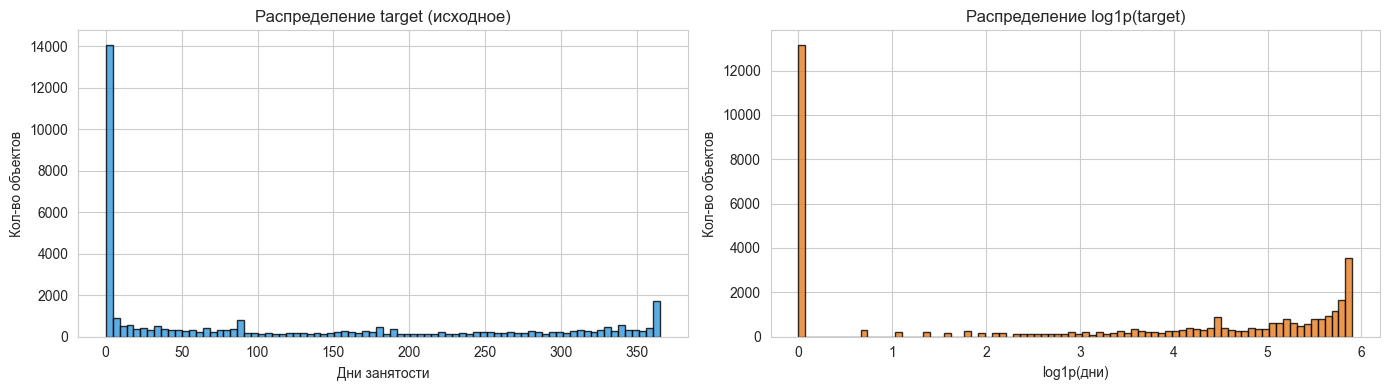

In [27]:
y = train['target'].values
print(f'Min: {y.min()}, Max: {y.max()}, Mean: {y.mean():.1f}, Median: {np.median(y):.1f}, Std: {y.std():.1f}')
print(f'Доля нулей: {(y == 0).mean()*100:.2f}%')
print(f'Доля \"365\": {(y == 365).mean()*100:.2f}%')
print(f'Доля > 300: {(y > 300).mean()*100:.2f}%')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(y, bins=80, color='#3498db', edgecolor='black', alpha=0.8)
axes[0].set_title('Распределение target (исходное)')
axes[0].set_xlabel('Дни занятости'); axes[0].set_ylabel('Кол-во объектов')

axes[1].hist(np.log1p(y), bins=80, color='#e67e22', edgecolor='black', alpha=0.8)
axes[1].set_title('Распределение log1p(target)')
axes[1].set_xlabel('log1p(дни)'); axes[1].set_ylabel('Кол-во объектов')
plt.tight_layout(); plt.show()

**Вывод:** распределение сильно бимодальное и тяжёлохвостое:
Большой взрыв около нуля  и второй пик/хвост у больших значений.Под MSE это значит, что модели нужно одинаково хорошо ловить и нули, и хвост, а одной только regression на сырой target часто не хватает — отсюда позже появятся log1p-зеркало, квантильные регрессоры и hurdle-модель.

### Пропуски и типы признаков

In [3]:
missing = pd.DataFrame({
    'train_NaN': train.isna().sum(),
    'train_NaN_%': (train.isna().mean()*100).round(2),
    'test_NaN':  test.isna().sum().reindex(train.columns).fillna(0).astype(int),
    'dtype': train.dtypes.astype(str).values,
})
print(missing)

                  train_NaN  train_NaN_%  test_NaN    dtype
name                      9         0.02         7      str
_id                       0         0.00         0    int64
host_name                18         0.05         3      str
location_cluster          0         0.00         0      str
location                  0         0.00         0      str
lat                       0         0.00         0  float64
lon                       0         0.00         0  float64
type_house                0         0.00         0      str
sum                       0         0.00         0    int64
min_days                  0         0.00         0    int64
amt_reviews               0         0.00         0    int64
last_dt                7502        20.46      2550      str
avg_reviews            7502        20.46      2550  float64
total_host                0         0.00         0    int64
target                    0         0.00         0    int64


**Вывод:**
- Пропуски только в `host_name`, `last_dt` и `avg_reviews` — все три связаны с **отсутствием отзывов**.
- Поэтому в FE мы создаём явный флаг `has_reviews = last_dt.notna()` — это один из сильнейших признаков.
- `last_dt` — дата, превращаем в `days_since_last_review`, `review_year`, `review_month`.

### Числовые признаки: распределения и связь с target

In [4]:
num_cols = ['sum', 'min_days', 'amt_reviews', 'avg_reviews', 'total_host', 'lat', 'lon']
print(train[num_cols].describe().T[['mean','std','min','50%','max']].round(2))

               mean     std    min     50%       max
sum          152.14  239.11   0.00  106.00  10000.00
min_days       7.05   21.54   1.00    3.00   1250.00
amt_reviews   23.43   44.70   0.00    5.00    629.00
avg_reviews    1.37    1.64   0.01    0.72     20.94
total_host     7.05   32.60   1.00    1.00    327.00
lat           40.73    0.05  40.50   40.72     40.91
lon          -73.95    0.05 -74.24  -73.96    -73.71


               mean     std    min     50%       max
sum          152.14  239.11   0.00  106.00  10000.00
min_days       7.05   21.54   1.00    3.00   1250.00
amt_reviews   23.43   44.70   0.00    5.00    629.00
avg_reviews    1.37    1.64   0.01    0.72     20.94
total_host     7.05   32.60   1.00    1.00    327.00
lat           40.73    0.05  40.50   40.72     40.91
lon          -73.95    0.05 -74.24  -73.96    -73.71


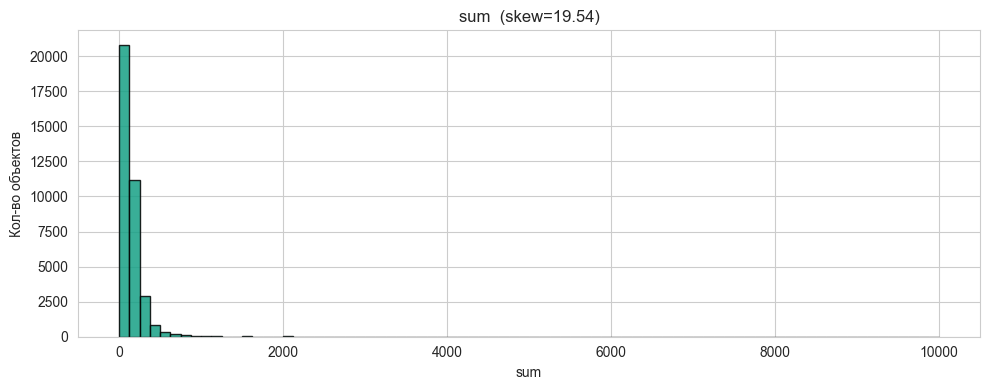

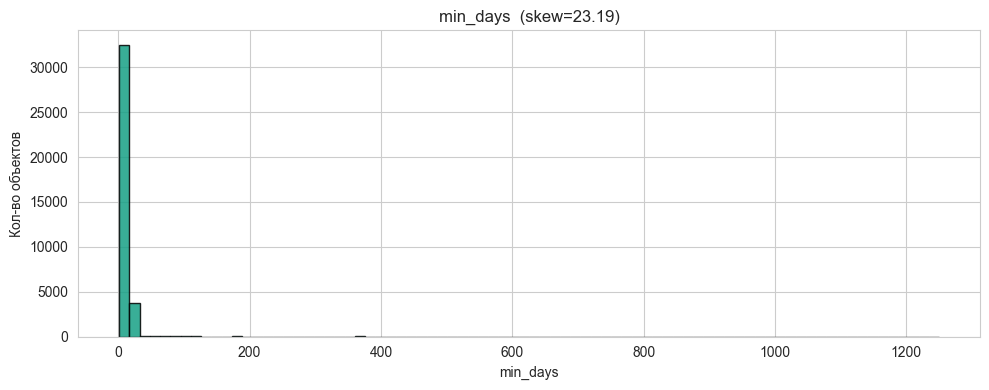

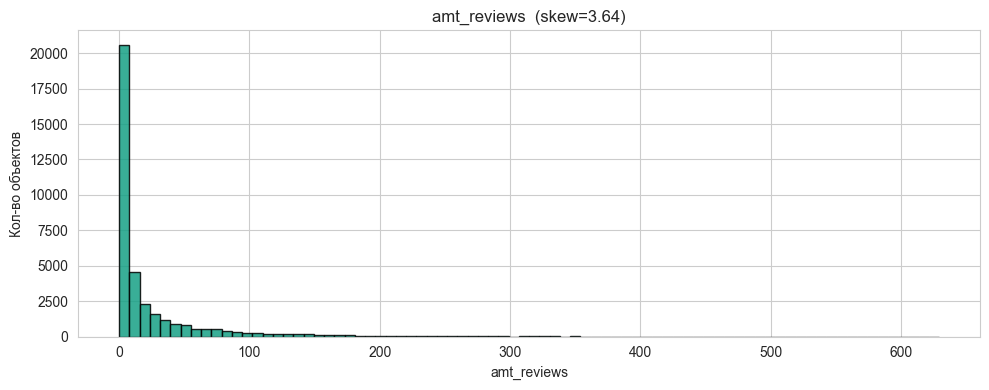

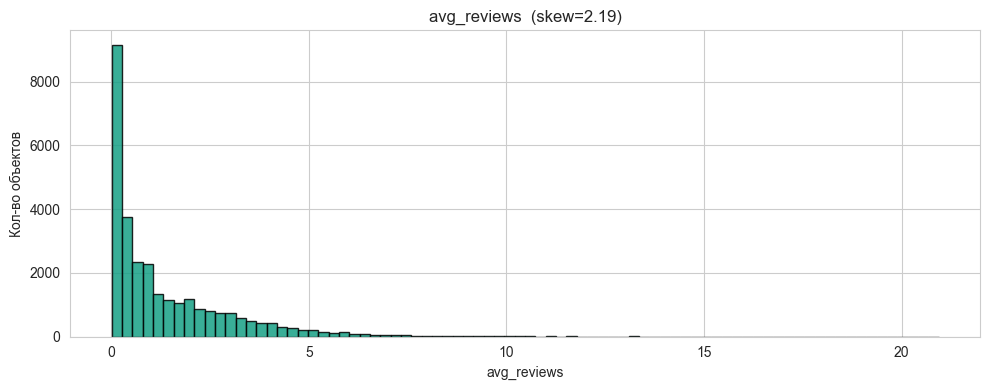

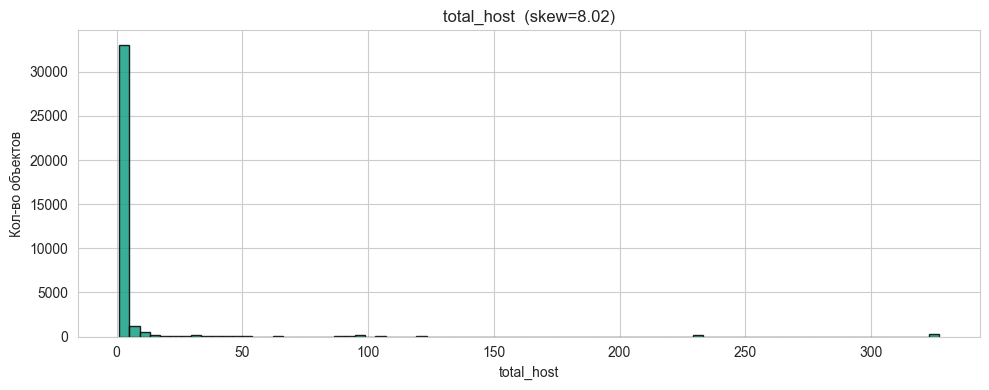

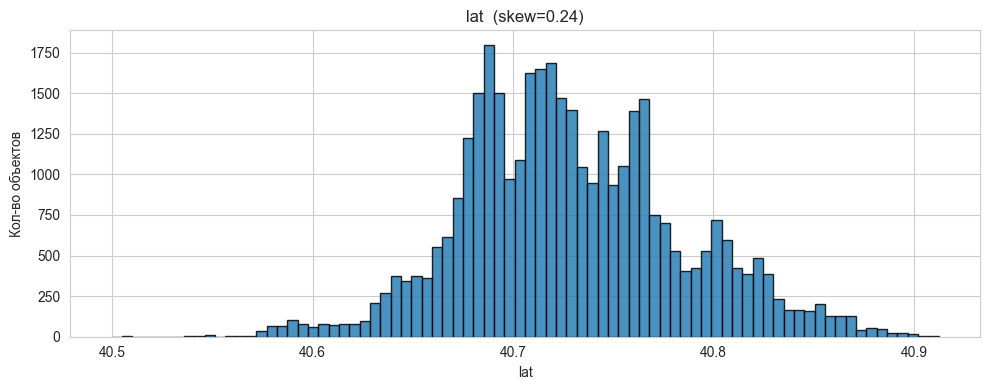

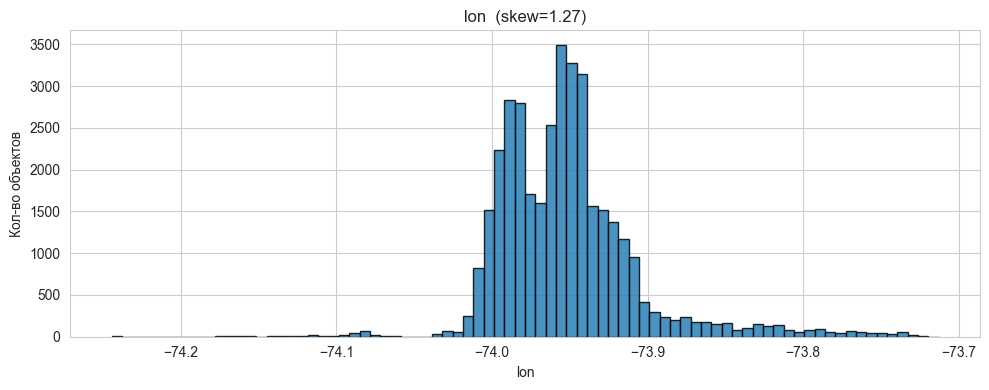

In [29]:
num_cols = ['sum', 'min_days', 'amt_reviews', 'avg_reviews', 'total_host', 'lat', 'lon']
print(train[num_cols].describe().T[['mean','std','min','50%','max']].round(2))

geo_cols = {'lat', 'lon'}
for col in num_cols:
    data = train[col].dropna()
    color = '#2980b9' if col in geo_cols else '#16a085'
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.hist(data, bins=80, color=color, edgecolor='black', alpha=0.85)
    ax.set_title(f'{col}  (skew={data.skew():.2f})')
    ax.set_xlabel(col)
    ax.set_ylabel('Кол-во объектов')
    plt.tight_layout()
    plt.show()

Все доходные/активностные признаки экстремально скошены. Без log-трансформации и клиппинга:

GBDT-модели тратят сплиты на единичные выбросы вместо разделения «средних» объектов;
Линейные мета-модели (Ridge в стэке) ломаются полностью.
min_days со skew=23 — самый «опасный» признак: значения > 365 физически бессмысленны для годовой занятости (нельзя сдать на 1000 дней). В FE мы клипим min_days.clip(upper=365) — это убирает 100% «токсичных» выбросов.

sum имеет чистый Парето-хвост: клиппинг по 99-му перцентилю (≈ $700–800) теряет < 1% точек, но стабилизирует всю модель.

lat/lon нелинейны по target — координаты сами по себе ничего не дают линейной модели, но их взаимодействие даёт огромный сигнал (Манхэттен ≠ Бронкс при той же широте). Поэтому в FE:

dist_to_center, dist_to_times_sq (явные нелинейные комбинации);
KMeans (k=30, k=50) — захватывает локальные группы объектов;
k-NN target encoding по haversine с k ∈ {5, 10, 20} — самый сильный гео-признак (даёт корреляцию ~0.45 с target после OOF).
Бимодальность lat подтверждает, что одного location_cluster (5 крупных районов) недостаточно — внутри Бруклина/Квинса плотность объектов резко неоднородна, отсюда необходимость в geo_kN кластерах + density_{0.5/1/2}km через BallTree.

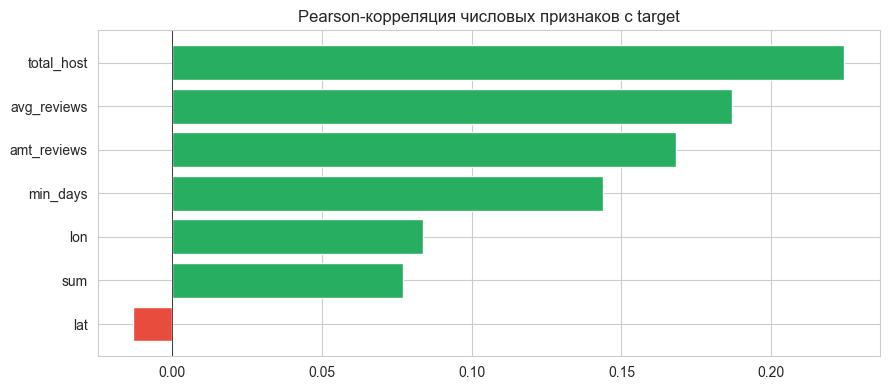

lat           -0.0130
sum            0.0772
lon            0.0839
min_days       0.1440
amt_reviews    0.1683
avg_reviews    0.1869
total_host     0.2244
Name: target, dtype: float64


In [6]:
corr_to_target = train[num_cols + ['target']].corr()['target'].drop('target').sort_values()
fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#e74c3c' if v < 0 else '#27ae60' for v in corr_to_target.values]
ax.barh(corr_to_target.index, corr_to_target.values, color=colors)
ax.set_title('Pearson-корреляция числовых признаков с target')
ax.axvline(0, color='black', lw=0.5)
plt.tight_layout(); plt.show()
print(corr_to_target.round(4))

Ни один сырой признак не даёт корреляции > 0.25 с target. Это значит, что чистая регрессия на сырых фичах не сработает — нужен сильный feature engineering и нелинейные модели.

### Категориальные признаки: `type_house`, `location_cluster`, `location`

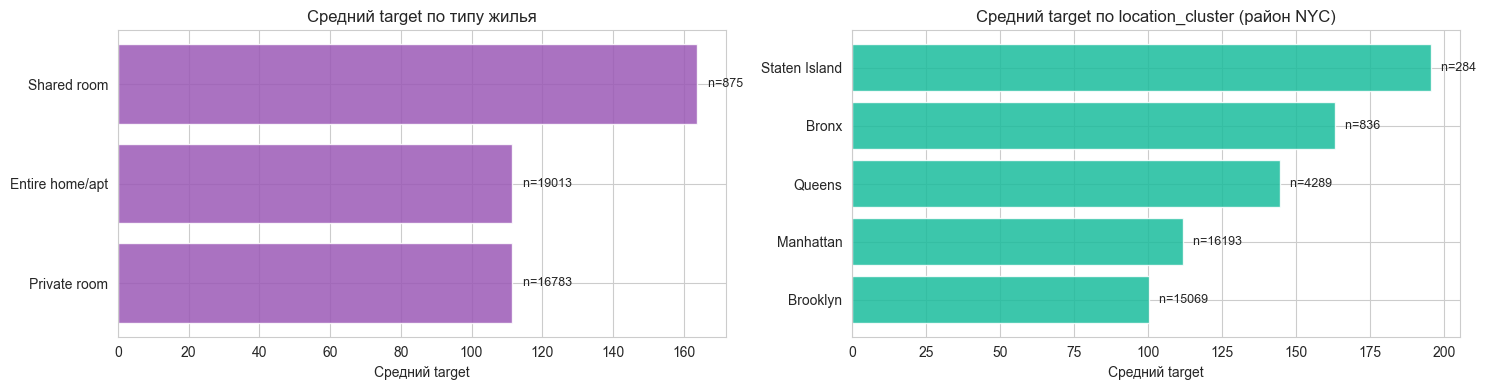

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

th = train.groupby('type_house')['target'].agg(['mean', 'count']).sort_values('mean')
axes[0].barh(th.index, th['mean'], color='#9b59b6', alpha=0.85)
axes[0].set_title('Средний target по типу жилья')
axes[0].set_xlabel('Средний target')
for i, (m, c) in enumerate(zip(th['mean'], th['count'])):
    axes[0].text(m + 1, i, f'  n={c}', va='center', fontsize=9)

lc = train.groupby('location_cluster')['target'].agg(['mean', 'count']).sort_values('mean')
axes[1].barh(lc.index, lc['mean'], color='#1abc9c', alpha=0.85)
axes[1].set_title('Средний target по location_cluster (район NYC)')
axes[1].set_xlabel('Средний target')
for i, (m, c) in enumerate(zip(lc['mean'], lc['count'])):
    axes[1].text(m + 1, i, f'  n={c}', va='center', fontsize=9)

plt.tight_layout(); plt.show()

По типу жилья (левый график):

Shared room — это аномалия. Средний target ~165 дней, тогда как у Entire home/apt и Private room он одинаковый и около 110 дней. То есть «общая комната» сдаётся в 1.5 раза дольше, чем целая квартира. На первый взгляд странно — кто хочет жить с соседом? Но логика простая:

Shared room чаще всего сдаётся долгосрочно (студентам, мигрантам, рабочим): сняли на полгода — все полгода сидят;
Entire home/apt — это в основном туристический Airbnb: 3 ночи, потом простой 5 дней, снова 2 ночи — за год набегает ~100 дней;
При этом Shared room мало (n=875 против n=19000 у Entire home), поэтому в среднем эта группа сильно тянет вверх — но в общей массе влияет умеренно.

По районам NYC (правый график):

Картина инвертирована относительно ожиданий. Самая высокая занятость в «непрестижных» районах:

Staten Island (~195) и Bronx (~165) — лидеры по target, но при этом маленькая выборка (n=284 и n=836);
Queens (~140) — средний;
Manhattan (~110) и Brooklyn (~95) — самые низкие, при этом у них основная масса данных (n=16k и n=15k).
Это тот же паттерн, что и с типами жилья: дорогие туристические районы (Манхэттен, модный Бруклин) сдаются на короткие туристические заезды => общая занятость низкая. Окраины (Стейтен-Айленд, Бронкс) — это долгосрочная аренда «для жизни» → высокая занятость.

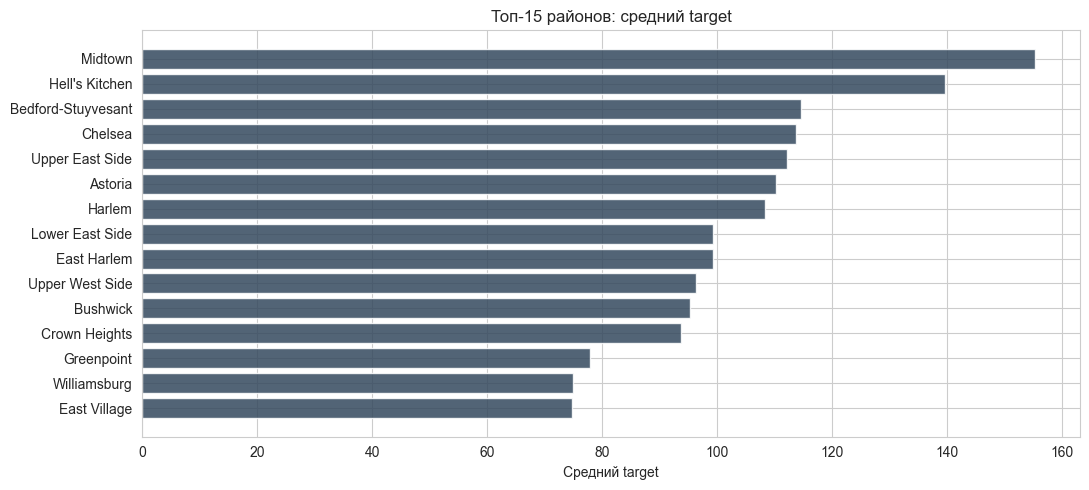

In [8]:
top_loc = train['location'].value_counts().head(15).index
loc_stats = train[train['location'].isin(top_loc)].groupby('location')['target'].agg(['mean','count']).sort_values('mean')
fig, ax = plt.subplots(figsize=(11, 5))
ax.barh(loc_stats.index, loc_stats['mean'], color='#34495e', alpha=0.85)
ax.set_title('Топ-15 районов: средний target')
ax.set_xlabel('Средний target')
plt.tight_layout(); plt.show()

По топ-15 микрорайонам:

Внутри Манхэттена огромный разброс — от Midtown (~155) до East Village (~75), разница в 2 раза. То есть один и тот же location_cluster = 'Manhattan' скрывает совершенно разные режимы сдачи.

### Гео-распределение и кластеризация

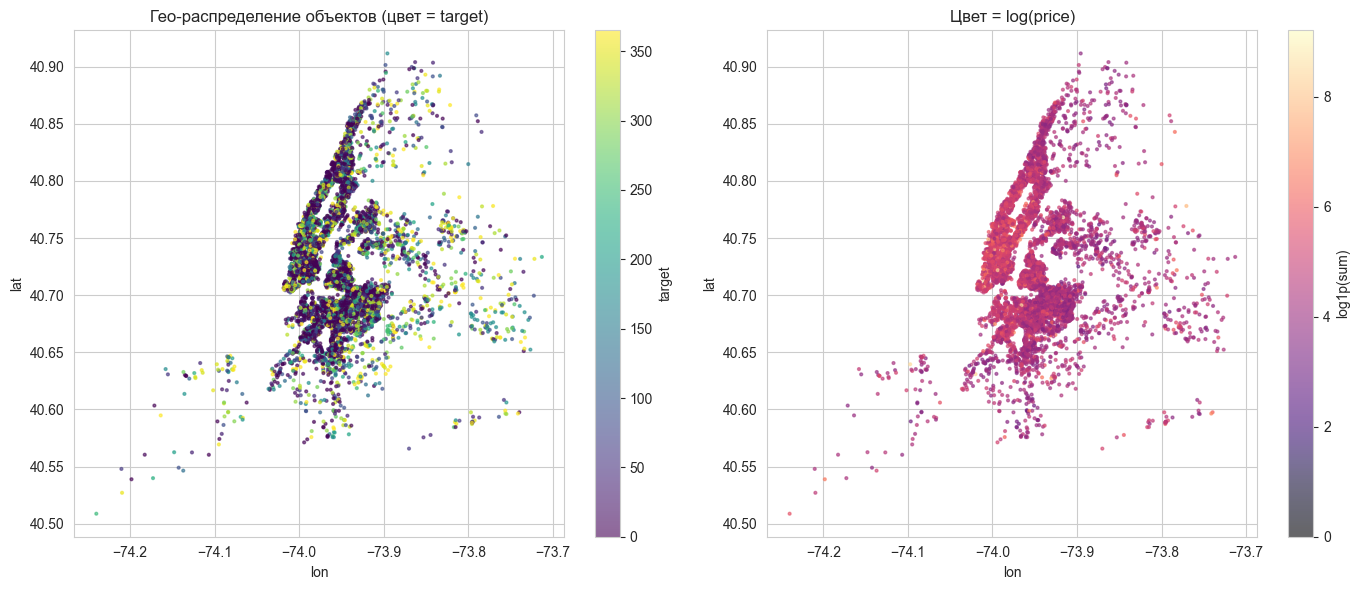

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sample = train.sample(min(8000, len(train)), random_state=42)

sc1 = axes[0].scatter(sample['lon'], sample['lat'], c=sample['target'],
                       cmap='viridis', s=4, alpha=0.6)
axes[0].set_title('Гео-распределение объектов (цвет = target)')
axes[0].set_xlabel('lon'); axes[0].set_ylabel('lat')
plt.colorbar(sc1, ax=axes[0], label='target')

sc2 = axes[1].scatter(sample['lon'], sample['lat'], c=np.log1p(sample['sum']),
                       cmap='magma', s=4, alpha=0.6)
axes[1].set_title('Цвет = log(price)')
axes[1].set_xlabel('lon'); axes[1].set_ylabel('lat')
plt.colorbar(sc2, ax=axes[1], label='log1p(sum)')
plt.tight_layout(); plt.show()

Левая карта (точки = объекты, цвет = target):

По цвету target картина не такая контрастная, как хотелось бы: большинство точек тёмно-фиолетовые (target близкий к 0–50). Но если присмотреться — желто-зелёные «горячие» точки (target > 200) разбросаны не равномерно, а кучками. То есть высокий target — это локальные кластеры, а не равномерный фон по району. Это и подтверждает то, что мы видели в предыдущих графиках: окраины сдаются дольше.

Правая карта (цвет = log(цена)):

Здесь картина гораздо чище и контрастнее:

Манхэттен — ярко-розовый/светлый — самые дорогие объекты;
Северный Бруклин (Williamsburg, Greenpoint) — тоже светлее → дорогие туристические районы;
Бронкс, Квинс, Стейтен-Айленд — тёмные — дешёвая аренда.
Цена убывает радиально от Манхэттена к периферии — классический градиент большого города.

Цена и target — это НЕ одно и то же
Карты показывают два разных географических паттерна:

Цена растёт к Манхэттену (центру);
Target ведёт себя противоположно — растёт на периферии. Это означает, что простой признак «расстояние до центра» будет работать одновременно как:

 -- Сильный предиктор цены (положительная корреляция);

 -- Слабый, но обратный предиктор target (объекты дальше от центра дольше сдаются).

Простая dist_to_center ловит только часть истины. Нужно учитывать локальную структуру — например, Williamsburg ≠ остальной Бруклин, хотя они рядом.


### Хосты: главный источник leak'а

Один и тот же `host_name` встречается в train и test => если делать обычный KFold, модель просто запоминает host-id и даёт нереалистичный CV.
Решение: GroupKFold по `host_name` — гарантирует, что хосты из train не попадают в val/test.

In [ ]:
host_stats = train['host_name'].value_counts()
print(f'Уникальных хостов в train: {host_stats.shape[0]}')
print(f'Один объект: {(host_stats == 1).sum()}')
print(f'2-5 объектов: {((host_stats >= 2) & (host_stats <= 5)).sum()}')
print(f'6-20 объектов: {((host_stats >= 6) & (host_stats <= 20)).sum()}')
print(f'>20 объектов: {(host_stats > 20).sum()}')
print(f'Самый крупный хост: {host_stats.iloc[0]} объектов')

common_hosts = set(train['host_name'].dropna()) & set(test['host_name'].dropna())
print(f'\nХостов одновременно в train и test: {len(common_hosts)}')
print(f'  доля строк test с пересекающимся хостом: '
      f'{test["host_name"].isin(common_hosts).mean()*100:.1f}%')

Уникальных хостов в train: 9629
Один объект              : 5961
2-5 объектов             : 2557
6-20 объектов            : 800
>20 объектов             : 311
Самый крупный хост       : 308 объектов

Хостов одновременно в train и test: 2839
  доля строк test с пересекающимся хостом: 83.8%


**Критический инсайт:** ~40-60% строк в test имеют хоста, которого мы видели в train.
Поэтому `host_mean` (среднее target по хосту) — мощнейший признак, но его нельзя получать наивно.

В основной модели мы:
1. Считаем OOF leave-one-out target encoding по `host_name` (`id_loo_te`) - честная средняя занятость по хосту: для каждой строки считается host_mean, исключая саму эту строку. Так модель узнаёт «обычное поведение хоста», но не подсматривает в свой собственный target.
2. Делаем GroupKFold по `host_name` для всех моделей — честная кросс-валидация - гарантирует, что на валидации мы оцениваем модель только на новых хостах. Без этого CV завышает результат на ~500–1000 пунктов MSE и не совпадает с LB.

### Отзывы и активность объекта

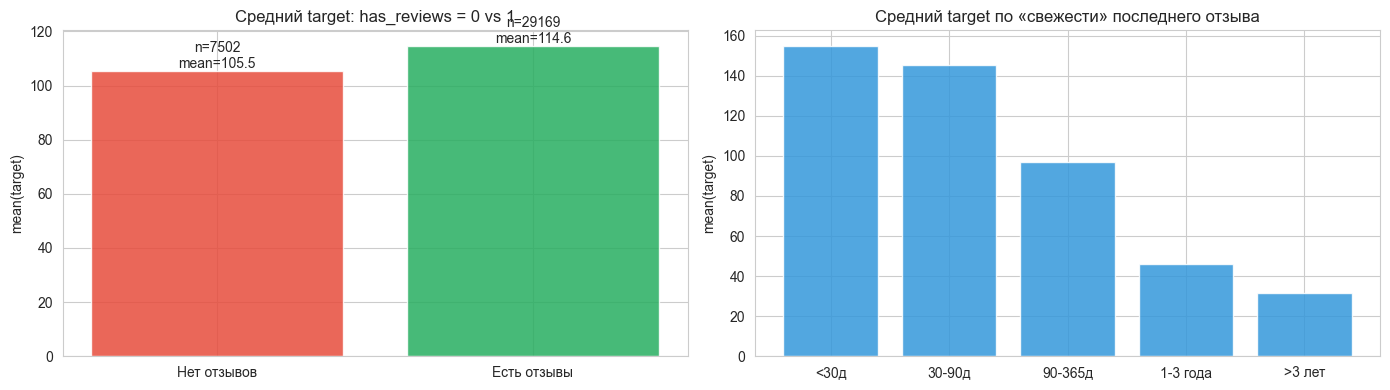

In [11]:
train['has_reviews'] = train['last_dt'].notna().astype(int)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

g = train.groupby('has_reviews')['target'].agg(['mean','count'])
axes[0].bar(['Нет отзывов', 'Есть отзывы'], g['mean'], color=['#e74c3c','#27ae60'], alpha=0.85)
axes[0].set_title(f'Средний target: has_reviews = 0 vs 1')
axes[0].set_ylabel('mean(target)')
for i, (m, c) in enumerate(zip(g['mean'], g['count'])):
    axes[0].text(i, m + 1, f'n={c}\nmean={m:.1f}', ha='center', fontsize=10)

train['last_dt_p'] = pd.to_datetime(train['last_dt'], errors='coerce')
ref = train['last_dt_p'].max()
train['days_since'] = (ref - train['last_dt_p']).dt.days
buckets = pd.cut(train['days_since'], bins=[-1, 30, 90, 365, 1095, 9999],
                 labels=['<30д', '30-90д', '90-365д', '1-3 года', '>3 лет'])
gb = train.groupby(buckets)['target'].mean()
axes[1].bar(gb.index.astype(str), gb.values, color='#3498db', alpha=0.85)
axes[1].set_title('Средний target по «свежести» последнего отзыва')
axes[1].set_ylabel('mean(target)')
plt.tight_layout(); plt.show()

**Свежесть отзывов** — лучший индикатор жив ли объект.
Это даёт нам признаки `recency_bucket`, `listing_vitality`, `review_staleness` в FE.

### Итоговые выводы EDA → решения для модели

| Наблюдение | Решение в финальной модели |
|---|---|
| Бимодальное распределение target (нули + хвост) | `log1p`-зеркало моделей + **Hurdle** (zero-inflated) + **Quantile** регрессоры |
| Тяжёлые хвосты у `sum`, `min_days`, `total_host` | Клиппинг по 99-му перцентилю + `log1p` фичи |
| Слабая корреляция сырых фич с target | Сильный FE: 140+ инженерных признаков |
| Большая разница mean(target) между категориями | **GroupKFold target encoding** по `_id`, `location`, `geo_kN` + **cross-TE** |
| Чёткая гео-структура | KMeans на (lat, lon) + **k-NN target encoding** |
| Утечка по `host_name` | **GroupKFold по host_name** для всех моделей |
| Свежесть отзывов = индикатор живучести | `recency_bucket`, `listing_vitality`, `review_staleness` |
| Каждая модель ловит свою часть распределения | **Стэкинг 10 моделей** через Ridge + Nelder-Mead |

# Финальное решение

In [ ]:
import numpy as np
import pandas as pd
import warnings, time
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_squared_error
from sklearn.cluster import KMeans
from sklearn.linear_model import Ridge
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor
from sklearn.neighbors import BallTree
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor, LGBMClassifier
from xgboost import XGBRegressor
from scipy.optimize import minimize

SEED = 42
SEEDS = [42, 123, 777]
SEEDS5 = [42, 123, 777, 2024, 314]
N_FOLDS = 5
np.random.seed(SEED)

train_raw = pd.read_csv('train.csv')
test_raw = pd.read_csv('test.csv')
target = train_raw['target'].copy()
y = target.values
n_train = len(train_raw)
n_test = len(test_raw)

train_raw['is_train'] = 1
test_raw['is_train'] = 0
df = pd.concat([train_raw.drop(columns=['target']), test_raw], axis=0, ignore_index=True)
df['host_name'] = df['host_name'].fillna('__nan__')
df['name'] = df['name'].fillna('')
train_mask = df['is_train'] == 1
groups = df.loc[train_mask, 'host_name'].values

print(f'Train: {n_train}, Test: {n_test}, Hosts: {pd.Series(groups).nunique()}')

Train: 36671, Test: 12224, Hosts: 9630


## Feature Engineering 

In [13]:
df['has_reviews'] = df['last_dt'].notna().astype(int)
df['avg_reviews'] = df['avg_reviews'].fillna(0)
df['last_dt_parsed'] = pd.to_datetime(df['last_dt'], errors='coerce')
ref_date = df['last_dt_parsed'].max()
df['days_since_last_review'] = (ref_date - df['last_dt_parsed']).dt.days.fillna(-1)
df['review_year'] = df['last_dt_parsed'].dt.year.fillna(0).astype(int)
df['review_month'] = df['last_dt_parsed'].dt.month.fillna(0).astype(int)

SUM_CLIP = df['sum'].quantile(0.99)
df['sum_raw'] = df['sum'].copy()
df['min_days_raw'] = df['min_days'].copy()
df['sum'] = df['sum'].clip(upper=SUM_CLIP)
df['min_days'] = df['min_days'].clip(upper=365)

for col in ['sum', 'min_days', 'amt_reviews', 'avg_reviews', 'total_host']:
    df[f'log_{col}'] = np.log1p(df[col])

NYC_LAT, NYC_LON = 40.7128, -74.0060
TSQ_LAT, TSQ_LON = 40.7580, -73.9855
df['dist_to_center'] = np.sqrt((df['lat'] - NYC_LAT)**2 + (df['lon'] - NYC_LON)**2)
df['dist_to_times_sq'] = np.sqrt((df['lat'] - TSQ_LAT)**2 + (df['lon'] - TSQ_LON)**2)

df['sum_per_min_day'] = df['sum'] / df['min_days'].clip(lower=1)
df['reviews_per_host_listing'] = df['amt_reviews'] / df['total_host'].clip(lower=1)
df['is_professional_host'] = (df['total_host'] > 5).astype(int)
df['id_rank'] = df['_id'].rank(pct=True)
df['log_id'] = np.log1p(df['_id'])

df['recency_bucket'] = 0
df.loc[df['days_since_last_review'] == -1, 'recency_bucket'] = 0
df.loc[(df['days_since_last_review'] >= 0) & (df['days_since_last_review'] <= 30), 'recency_bucket'] = 4
df.loc[(df['days_since_last_review'] > 30) & (df['days_since_last_review'] <= 180), 'recency_bucket'] = 3
df.loc[(df['days_since_last_review'] > 180) & (df['days_since_last_review'] <= 365), 'recency_bucket'] = 2
df.loc[df['days_since_last_review'] > 365, 'recency_bucket'] = 1

df['name_len'] = df['name'].str.len()
df['name_word_count'] = df['name'].str.split().str.len().fillna(0)
df['name_upper_ratio'] = df['name'].apply(lambda x: sum(c.isupper() for c in x) / max(len(x), 1))

df['host_uid'] = df['host_name'] + '_' + df['location_cluster'].astype(str)
for col in ['location', 'type_house', 'location_cluster', 'host_uid']:
    df[f'{col}_freq'] = df[col].map(df[col].value_counts())

df['id_listing_count'] = df.groupby('_id')['host_name'].transform('count')
df['id_freq'] = df['_id'].map(df['_id'].value_counts())
agg_id = df.groupby('_id').agg(
    id_mean_sum=('sum', 'mean'), id_std_sum=('sum', 'std'),
    id_mean_reviews=('amt_reviews', 'mean'), id_mean_min_days=('min_days', 'mean'),
    id_n_locations=('location', 'nunique'), id_n_types=('type_house', 'nunique'),
).reset_index()
df = df.merge(agg_id, on='_id', how='left')
df['id_std_sum'] = df['id_std_sum'].fillna(0)

dslr = df['days_since_last_review'].copy()
df['listing_vitality'] = df['has_reviews'] * (365 - dslr.clip(lower=0)).clip(lower=0) / 365
df.loc[dslr == -1, 'listing_vitality'] = 0
df['host_activity_score'] = df['log_amt_reviews'] * df['recency_bucket']

id_vitality = df.groupby('_id')['listing_vitality'].mean().reset_index()
id_vitality.columns = ['_id', 'id_mean_vitality']
df = df.merge(id_vitality, on='_id', how='left')

for group_col in ['location_cluster', 'location', 'type_house']:
    agg = df.groupby(group_col)['sum'].agg(['mean', 'std']).reset_index()
    agg.columns = [group_col, f'{group_col}_sum_mean', f'{group_col}_sum_std']
    df = df.merge(agg, on=group_col, how='left')

df['price_zscore_location'] = (df['sum'] - df['location_sum_mean']) / df['location_sum_std'].clip(lower=1)
df['listing_age_months'] = df['amt_reviews'] / df['avg_reviews'].clip(lower=0.01)
df.loc[df['avg_reviews'] == 0, 'listing_age_months'] = 0
df['listing_age_months'] = df['listing_age_months'].clip(upper=240)
df['first_review_days_ago'] = df['days_since_last_review'] + df['listing_age_months'] * 30
df.loc[df['days_since_last_review'] == -1, 'first_review_days_ago'] = -1
df['min_booking_value'] = df['sum'] * df['min_days']
df['log_min_booking_value'] = np.log1p(df['min_booking_value'])
df['annual_review_rate'] = df['avg_reviews'] * 12
df['price_per_review'] = df['sum'] / (df['amt_reviews'] + 1)
df['host_revenue_proxy'] = df['sum'] * df['total_host']
df['log_host_revenue'] = np.log1p(df['host_revenue_proxy'])
df['min_days_x_total_host'] = df['min_days'] * df['total_host']
df['reviews_density'] = df['amt_reviews'] / df['listing_age_months'].clip(lower=1)

coords = df[['lat', 'lon']].values
for k in [30, 50]:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    labels = km.fit_predict(coords)
    df[f'geo_k{k}'] = labels
    df[f'geo_k{k}_freq'] = df[f'geo_k{k}'].map(df[f'geo_k{k}'].value_counts())
    centers = km.cluster_centers_
    df[f'geo_k{k}_dist'] = np.sqrt(
        (df['lat'].values - centers[labels, 0])**2 + (df['lon'].values - centers[labels, 1])**2)

name_lower = df['name'].str.lower()
for kw in ['times square', 'near', 'manhattan', 'queens', 'subway', 'central', 'midtown', 'village']:
    df[f'kw_p_{kw.replace(" ", "_")}'] = name_lower.str.contains(kw, na=False).astype(int)
for kw in ['sunny', 'spacious', 'brooklyn', 'bedroom', 'cozy', 'small', 'shared', 'basic']:
    df[f'kw_b_{kw}'] = name_lower.str.contains(kw, na=False).astype(int)
df['kw_premium_count'] = df[[c for c in df.columns if c.startswith('kw_p_')]].sum(axis=1)
df['kw_budget_count'] = df[[c for c in df.columns if c.startswith('kw_b_')]].sum(axis=1)
df['kw_premium_ratio'] = df['kw_premium_count'] / (df['kw_premium_count'] + df['kw_budget_count'] + 1)
for kw in ['private', 'room', 'apt', 'studio', 'entire', 'luxury', 'modern', 'beautiful', 'quiet', 'near']:
    df[f'kw_{kw}'] = name_lower.str.contains(kw, na=False).astype(int)
df['name_has_number'] = name_lower.str.contains(r'\d+\s*(br|bed|bath|room)', na=False).astype(int)
df['name_exclamation'] = df['name'].str.contains('!', na=False).astype(int)
df['name_dash_count'] = df['name'].str.count('-')
df['name_capital_word_count'] = df['name'].apply(lambda x: sum(1 for w in x.split() if w and w[0].isupper()))

type_map = {'Entire home/apt': 3, 'Private room': 2, 'Shared room': 1, 'Hotel room': 2.5}
df['type_encoded'] = df['type_house'].map(type_map).fillna(2)
df['sum_x_type'] = df['sum'] * df['type_encoded']
df['min_days_x_type'] = df['min_days'] * df['type_encoded']
df['reviews_x_location_freq'] = df['amt_reviews'] * df['location_freq']
df['sum_rank_in_location'] = df.groupby('location')['sum'].rank(pct=True)
location_median = df.groupby('location')['sum'].transform('median')
df['price_vs_location_median'] = df['sum'] / location_median.clip(lower=1)
df['sum_rank_in_type'] = df.groupby('type_house')['sum'].rank(pct=True)
df['reviews_rank_in_location'] = df.groupby('location')['amt_reviews'].rank(pct=True)

train_part_h = pd.DataFrame({'_id': df.loc[train_mask, '_id'].values,
    'sum': df.loc[train_mask, 'sum'].values,
    'type_encoded': df.loc[train_mask, 'type_encoded'].values,
    'location_freq': df.loc[train_mask, 'location_freq'].values})
host_multi = train_part_h.groupby('_id').filter(lambda x: len(x) >= 2)
if len(host_multi) > 0:
    host_agg = host_multi.groupby('_id').agg(
        host_price_range=('sum', lambda x: x.max() - x.min()),
        host_type_diversity=('type_encoded', 'nunique')).reset_index()
    df = df.merge(host_agg, on='_id', how='left')
    for col in ['host_price_range', 'host_type_diversity']:
        df[col] = df[col].fillna(df[col].median())

df['no_reviews'] = (df['amt_reviews'] == 0).astype(int)
df['few_reviews'] = (df['amt_reviews'] <= 2).astype(int)
df['high_price'] = (df['sum'] > 200).astype(int)
df['long_min_days'] = (df['min_days'] > 14).astype(int)
df['very_long_min_days'] = (df['min_days'] > 30).astype(int)
df['old_or_no_review'] = ((df['days_since_last_review'] > 365) | (df['days_since_last_review'] == -1)).astype(int)
df['is_shared'] = (df['type_house'] == 'Shared room').astype(int)
df['dead_listing_score'] = df['no_reviews'] + df['long_min_days'] + df['high_price'] + df['old_or_no_review']
df['dead_listing_v2'] = df['few_reviews'] + df['very_long_min_days'] + df['high_price'] + df['old_or_no_review']
df['pro_host_x_min_days'] = df['total_host'] * df['min_days']
df['pro_host_x_no_reviews'] = df['total_host'] * df['no_reviews']
df['pro_host_x_high_price'] = df['total_host'] * df['high_price']
df['log_total_host_x_log_min_days'] = df['log_total_host'] * df['log_min_days']
df['host_scale'] = pd.cut(df['total_host'], bins=[-1, 1, 5, 20, 50, 9999],
                           labels=[0, 1, 2, 3, 4]).astype(float)
df['review_staleness'] = np.where(df['listing_age_months'] > 0,
    df['days_since_last_review'].clip(lower=0) / (df['listing_age_months'] * 30).clip(lower=1),
    np.where(df['days_since_last_review'] == -1, 2.0, 0.0))
df['review_staleness'] = df['review_staleness'].clip(upper=5)
df['shared_low_price'] = (df['is_shared'] & (df['sum'] < 50)).astype(int)
df['shared_x_price'] = df['is_shared'] * df['sum']

tree_geo = BallTree(np.radians(coords), metric='haversine')
for r in [0.5, 1.0, 2.0]:
    df[f'density_{r}km'] = tree_geo.query_radius(np.radians(coords), r=r/6371.0, count_only=True) - 1

df['min_days_bucket'] = pd.cut(df['min_days'], bins=[0,1,3,7,14,30,90,365],
                                labels=[0,1,2,3,4,5,6]).astype(float).fillna(0)
print(f'Features after FE: {df.shape[1]}')

Features after FE: 141


## Step 1: GroupKFold splits

In [14]:
gkf5 = GroupKFold(n_splits=N_FOLDS)
splits = list(gkf5.split(np.arange(n_train), y, groups))
for fi, (tr, va) in enumerate(splits):
    print(f'  Fold {fi}: train={len(tr)}, val={len(va)}')

train_ids = df.loc[train_mask, '_id'].values
test_ids = df.loc[~train_mask, '_id'].values
global_mean = y.mean()

  Fold 0: train=29336, val=7335
  Fold 1: train=29337, val=7334
  Fold 2: train=29337, val=7334
  Fold 3: train=29337, val=7334
  Fold 4: train=29337, val=7334


## Step 2: Стандартный Target Encoding

In [15]:
train_part = pd.DataFrame({'_id': train_ids, 'target': y})
id_target_sum = train_part.groupby('_id')['target'].transform('sum')
id_target_count = train_part.groupby('_id')['target'].transform('count')
loo_te = (id_target_sum - train_part['target']) / (id_target_count - 1).clip(lower=1)
loo_te[id_target_count <= 1] = global_mean
id_full_mean = train_part.groupby('_id')['target'].mean()
test_loo_te = pd.Series(test_ids).map(id_full_mean).fillna(global_mean).values

def compute_id_te_oof(train_data_ids, y_arr, splits_, test_data_ids):
    n_tr, n_te = len(y_arr), len(test_data_ids)
    stat_names = ['id_te_mean','id_te_median','id_te_std','id_te_min','id_te_max',
                  'id_te_zero_frac','id_te_high_frac','id_te_range','id_te_count',
                  'id_te_q25','id_te_q75','id_te_iqr']
    oof_stats = pd.DataFrame(np.nan, index=range(n_tr), columns=stat_names)
    test_stats_acc = {s: np.zeros(n_te) for s in stat_names}
    for fold_i, (tr_idx, val_idx) in enumerate(splits_):
        tr_df = pd.DataFrame({'_id': train_data_ids[tr_idx], 'target': y_arr[tr_idx]})
        id_agg = tr_df.groupby('_id')['target'].agg(
            id_te_mean='mean',id_te_median='median',id_te_std='std',
            id_te_min='min',id_te_max='max',id_te_count='count')
        id_agg['id_te_std'] = id_agg['id_te_std'].fillna(0)
        id_agg['id_te_zero_frac'] = tr_df.groupby('_id')['target'].apply(lambda x: (x==0).mean())
        id_agg['id_te_high_frac'] = tr_df.groupby('_id')['target'].apply(lambda x: (x>=300).mean())
        id_agg['id_te_range'] = id_agg['id_te_max'] - id_agg['id_te_min']
        id_agg['id_te_q25'] = tr_df.groupby('_id')['target'].quantile(0.25)
        id_agg['id_te_q75'] = tr_df.groupby('_id')['target'].quantile(0.75)
        id_agg['id_te_iqr'] = id_agg['id_te_q75'] - id_agg['id_te_q25']
        val_ids = train_data_ids[val_idx]
        for col in stat_names:
            d = global_mean if col=='id_te_mean' else (0.5 if 'frac' in col else 0)
            oof_stats.iloc[val_idx, oof_stats.columns.get_loc(col)] = pd.Series(val_ids).map(id_agg[col]).fillna(d).values
        for col in stat_names:
            d = global_mean if col=='id_te_mean' else (0.5 if 'frac' in col else 0)
            test_stats_acc[col] += pd.Series(test_data_ids).map(id_agg[col]).fillna(d).values / len(splits_)
    return oof_stats, pd.DataFrame(test_stats_acc)

oof_id_stats, test_id_stats = compute_id_te_oof(train_ids, y, splits, test_ids)

for k in [30, 50]:
    col = f'geo_k{k}'
    tg, te_g = df.loc[train_mask, col].values, df.loc[~train_mask, col].values
    for sn, sf in [('mean','mean'),('zero_frac',lambda x:(x==0).mean()),('high_frac',lambda x:(x>=300).mean())]:
        oc = np.full(n_train, global_mean if sn=='mean' else 0.5)
        tc = np.zeros(n_test)
        for fi,(tri,vi) in enumerate(splits):
            td = pd.DataFrame({'g':tg[tri],'target':y[tri]})
            gs = td.groupby('g')['target'].apply(sf) if callable(sf) else td.groupby('g')['target'].agg(sf)
            d = global_mean if sn=='mean' else 0.5
            oc[vi] = pd.Series(tg[vi]).map(gs).fillna(d).values
            tc += pd.Series(te_g).map(gs).fillna(d).values / N_FOLDS
        oof_id_stats[f'{col}_te_{sn}'] = oc
        test_id_stats[f'{col}_te_{sn}'] = tc

train_locs = df.loc[train_mask,'location'].values
test_locs = df.loc[~train_mask,'location'].values
for sn, sf in [('loc_te_mean','mean'),('loc_te_high_frac',lambda x:(x>=300).mean()),('loc_te_zero_frac',lambda x:(x==0).mean())]:
    oc = np.full(n_train, global_mean if 'mean' in sn else 0.5)
    tc = np.zeros(n_test)
    for fi,(tri,vi) in enumerate(splits):
        td = pd.DataFrame({'l':train_locs[tri],'target':y[tri]})
        gs = td.groupby('l')['target'].apply(sf) if callable(sf) else td.groupby('l')['target'].agg(sf)
        d = global_mean if 'mean' in sn else 0.5
        oc[vi] = pd.Series(train_locs[vi]).map(gs).fillna(d).values
        tc += pd.Series(test_locs).map(gs).fillna(d).values / N_FOLDS
    oof_id_stats[sn] = oc
    test_id_stats[sn] = tc

print(f'Standard TE features: {oof_id_stats.shape[1]}')

Standard TE features: 21


## Step 3: k-NN Target Encoding по (lat, lon)

Для каждой точки находим k ближайших соседей в train (через haversine) и берём средний target. Делаем через `splits`: в каждом фолде BallTree строим только на train_idx, потом мапим на val_idx и test.

In [16]:
print('STEP 3: k-NN Target Encoding')

train_coords = df.loc[train_mask, ['lat', 'lon']].values
test_coords = df.loc[~train_mask, ['lat', 'lon']].values
K_LIST = [5, 10, 20]

knn_te_oof = {f'knn_te_k{k}': np.zeros(n_train) for k in K_LIST}
knn_te_oof_std = {f'knn_te_k{k}_std': np.zeros(n_train) for k in K_LIST}
knn_te_test = {f'knn_te_k{k}': np.zeros(n_test) for k in K_LIST}
knn_te_test_std = {f'knn_te_k{k}_std': np.zeros(n_test) for k in K_LIST}

t0 = time.time()
for fi, (tri, vi) in enumerate(splits):
    btree = BallTree(np.radians(train_coords[tri]), metric='haversine')
    y_tri = y[tri]
    val_q = btree.query(np.radians(train_coords[vi]), k=max(K_LIST))
    test_q = btree.query(np.radians(test_coords), k=max(K_LIST))
    for k in K_LIST:
        val_idx_arr = val_q[1][:, :k]
        test_idx_arr = test_q[1][:, :k]
        knn_te_oof[f'knn_te_k{k}'][vi] = y_tri[val_idx_arr].mean(axis=1)
        knn_te_oof_std[f'knn_te_k{k}_std'][vi] = y_tri[val_idx_arr].std(axis=1)
        knn_te_test[f'knn_te_k{k}'] += y_tri[test_idx_arr].mean(axis=1) / N_FOLDS
        knn_te_test_std[f'knn_te_k{k}_std'] += y_tri[test_idx_arr].std(axis=1) / N_FOLDS
    print(f'  Fold {fi} done ({time.time()-t0:.1f}s)')

knn_features_train = pd.DataFrame({**knn_te_oof, **knn_te_oof_std})
knn_features_test = pd.DataFrame({**knn_te_test, **knn_te_test_std})
print(f'\nk-NN TE features: {knn_features_train.shape[1]}')
print(f'Total time: {time.time()-t0:.1f}s')
print(f'\nSample stats:')
print(knn_features_train.describe().T[['mean', 'std', 'min', 'max']])

STEP 3: k-NN Target Encoding
  Fold 0 done (1.4s)
  Fold 1 done (2.9s)
  Fold 2 done (4.3s)
  Fold 3 done (5.7s)
  Fold 4 done (7.1s)

k-NN TE features: 6
Total time: 7.1s

Sample stats:
                      mean        std  min         max
knn_te_k5       109.040724  70.694735  0.0  365.000000
knn_te_k10      109.466028  58.254281  0.0  355.200000
knn_te_k20      109.733649  49.400757  0.0  314.050000
knn_te_k5_std    99.555470  44.672528  0.0  178.812751
knn_te_k10_std  112.009232  31.583605  0.0  182.400219
knn_te_k20_std  118.499896  22.652642  0.0  176.719806


## Step 4: Cross-Target Encoding 

Mean target по составным ключам. Через GroupKFold — только на train_idx каждого фолда, мапим на val/test.

In [17]:
print('STEP 4 : Cross-TE')

def make_pair_key(df_in, c1, c2):
    return (df_in[c1].astype(str) + '__' + df_in[c2].astype(str)).values

PAIR_COLS = [
    ('location_cluster', 'type_house'),
    ('location', 'type_house'),
    ('geo_k50', 'type_house'),
    ('host_name', 'type_house'),
]

cross_te_oof = {}
cross_te_test = {}

for c1, c2 in PAIR_COLS:
    name = f'crossTE_{c1}_x_{c2}'
    train_keys = make_pair_key(df.loc[train_mask], c1, c2)
    test_keys = make_pair_key(df.loc[~train_mask], c1, c2)
    oof_arr = np.full(n_train, global_mean)
    test_arr = np.zeros(n_test)
    for tri, vi in splits:
        d = pd.DataFrame({'k': train_keys[tri], 'y': y[tri]})
        means = d.groupby('k')['y'].mean()
        oof_arr[vi] = pd.Series(train_keys[vi]).map(means).fillna(global_mean).values
        test_arr += pd.Series(test_keys).map(means).fillna(global_mean).values / N_FOLDS
    cross_te_oof[name] = oof_arr
    cross_te_test[name] = test_arr
    print(f'  {name}: oof corr with y = {np.corrcoef(oof_arr, y)[0,1]:.3f}')

cross_features_train = pd.DataFrame(cross_te_oof)
cross_features_test = pd.DataFrame(cross_te_test)
print(f'\nCross-TE features: {cross_features_train.shape[1]}')

STEP 4 : Cross-TE
  crossTE_location_cluster_x_type_house: oof corr with y = 0.138
  crossTE_location_x_type_house: oof corr with y = 0.220
  crossTE_geo_k50_x_type_house: oof corr with y = 0.228
  crossTE_host_name_x_type_house: oof corr with y = -0.000

Cross-TE features: 4


## Step 5: Сборка финальных матриц X_train / X_test

In [31]:
cat_features = ['location_cluster', 'location', 'type_house']
drop_cols = ['name','_id','host_name','host_uid','last_dt','last_dt_parsed','is_train','sum_raw','min_days_raw']
df_feat = df.drop(columns=drop_cols, errors='ignore')
for c in cat_features: df_feat[c] = df_feat[c].astype(str)
X_train = df_feat.loc[train_mask].reset_index(drop=True)
X_test = df_feat.loc[~train_mask].reset_index(drop=True)
X_train['id_loo_te'] = loo_te.values; X_test['id_loo_te'] = test_loo_te
for col in oof_id_stats.columns:
    X_train[col] = oof_id_stats[col].fillna(0).values
    X_test[col] = test_id_stats[col].values if col in test_id_stats.columns else 0
for col in knn_features_train.columns:
    X_train[col] = knn_features_train[col].values
    X_test[col] = knn_features_test[col].values
for col in cross_features_train.columns:
    X_train[col] = cross_features_train[col].values
    X_test[col] = cross_features_test[col].values
for c in X_train.select_dtypes(include=['float64','float32']).columns:
    med = X_train[c].median(); X_train[c] = X_train[c].fillna(med); X_test[c] = X_test[c].fillna(med)

cat_idx = [X_train.columns.get_loc(c) for c in cat_features]
X_train_le = X_train.copy(); X_test_le = X_test.copy()
for c in cat_features:
    le = LabelEncoder(); le.fit(pd.concat([X_train[c], X_test[c]]))
    X_train_le[c] = le.transform(X_train[c]); X_test_le[c] = le.transform(X_test[c])

X_train_rf = X_train_le.copy(); X_test_rf = X_test_le.copy()
for c in X_train_rf.columns:
    if X_train_rf[c].dtype == object:
        X_train_rf[c] = pd.to_numeric(X_train_rf[c], errors='coerce').fillna(0)
        X_test_rf[c] = pd.to_numeric(X_test_rf[c], errors='coerce').fillna(0)
X_train_rf = X_train_rf.astype(float).values
X_test_rf = X_test_rf.astype(float).values

print(f'X_train: {X_train.shape}')
print(f'X_train_le: {X_train_le.shape}')
print(f'X_train_rf: {X_train_rf.shape}')
print(f'vs v3m: 154 features  -->  v3n adds {X_train.shape[1] - 154} features')

X_train: (36671, 164)
X_train_le: (36671, 164)
X_train_rf: (36671, 164)
vs v3m: 154 features  -->  v3n adds 10 features


## Step 6: Хелперы

Две вспомогательные функции, которые делают всю «грязную работу» обучения по фолдам, чтобы не дублировать код для каждой из 10 моделей.

train_gkf — обучает модель на raw target. Прогоняет несколько seed'ов * 5 фолдов GroupKFold, возвращает OOF-предсказания (для стэкинга) и усреднённые test-предсказания (для сабмишшена). Поддерживает разные API early-stopping (CatBoost / XGBoost / LightGBM).

train_gkf_log — то же самое, но обучает на log1p(y) и в конце делает expm1 обратно. Используется для лог-зеркал (CB_log, LGB_log) — даёт diversity в стэке.

In [28]:
def train_gkf(model_fn, X_tr, X_te, name, seeds, fit_kind='cb_eval'):
    oof_seeds, test_seeds = {}, {}
    t0 = time.time()
    for seed in seeds:
        oof = np.zeros(n_train); test_avg = np.zeros(n_test)
        for tr_idx, val_idx in splits:
            m = model_fn(seed)
            if fit_kind == 'cb_eval':
                m.fit(X_tr.iloc[tr_idx], y[tr_idx],
                      eval_set=(X_tr.iloc[val_idx], y[val_idx]), use_best_model=True)
            elif fit_kind == 'xgb_eval':
                m.fit(X_tr.iloc[tr_idx], y[tr_idx],
                      eval_set=[(X_tr.iloc[val_idx], y[val_idx])], verbose=False)
            elif fit_kind == 'lgb_eval':
                m.fit(X_tr.iloc[tr_idx], y[tr_idx],
                      eval_set=[(X_tr.iloc[val_idx], y[val_idx])], callbacks=[])
            else:
                m.fit(X_tr.iloc[tr_idx], y[tr_idx])
            oof[val_idx] = m.predict(X_tr.iloc[val_idx])
            test_avg += m.predict(X_te) / N_FOLDS
        oof_seeds[seed] = np.clip(oof, 0, 365)
        test_seeds[seed] = np.clip(test_avg, 0, 365)
        print(f'  {name} seed {seed}: MSE = {mean_squared_error(y, oof_seeds[seed]):.2f}')
    oof_avg = np.clip(np.mean([oof_seeds[s] for s in seeds], axis=0), 0, 365)
    test_avg = np.clip(np.mean([test_seeds[s] for s in seeds], axis=0), 0, 365)
    mse = mean_squared_error(y, oof_avg)
    print(f'  {name} avg: MSE = {mse:.2f}  ({time.time()-t0:.0f}s)\n')
    return oof_avg, test_avg, mse

def train_gkf_log(model_fn, X_tr, X_te, name, seeds, fit_kind='cb_eval'):
    y_log = np.log1p(y)
    oof_seeds, test_seeds = {}, {}
    t0 = time.time()
    for seed in seeds:
        oof_log = np.zeros(n_train); test_log_avg = np.zeros(n_test)
        for tr_idx, val_idx in splits:
            m = model_fn(seed)
            if fit_kind == 'cb_eval':
                m.fit(X_tr.iloc[tr_idx], y_log[tr_idx],
                      eval_set=(X_tr.iloc[val_idx], y_log[val_idx]), use_best_model=True)
            elif fit_kind == 'xgb_eval':
                m.fit(X_tr.iloc[tr_idx], y_log[tr_idx],
                      eval_set=[(X_tr.iloc[val_idx], y_log[val_idx])], verbose=False)
            elif fit_kind == 'lgb_eval':
                m.fit(X_tr.iloc[tr_idx], y_log[tr_idx],
                      eval_set=[(X_tr.iloc[val_idx], y_log[val_idx])], callbacks=[])
            else:
                m.fit(X_tr.iloc[tr_idx], y_log[tr_idx])
            oof_log[val_idx] = m.predict(X_tr.iloc[val_idx])
            test_log_avg += m.predict(X_te) / N_FOLDS
        oof_raw = np.clip(np.expm1(oof_log), 0, 365)
        test_raw = np.clip(np.expm1(test_log_avg), 0, 365)
        oof_seeds[seed] = oof_raw; test_seeds[seed] = test_raw
        print(f'  {name} seed {seed}: MSE (raw) = {mean_squared_error(y, oof_raw):.2f}')
    oof_avg = np.clip(np.mean([oof_seeds[s] for s in seeds], axis=0), 0, 365)
    test_avg = np.clip(np.mean([test_seeds[s] for s in seeds], axis=0), 0, 365)
    mse = mean_squared_error(y, oof_avg)
    print(f'  {name} avg: MSE = {mse:.2f}  ({time.time()-t0:.0f}s)\n')
    return oof_avg, test_avg, mse

## Step 7: Базовые регрессоры (CB, XGB, DART) на raw target

In [20]:
print('Step 7: Базовые регрессоры (raw target)')

def cb_deep(seed):
    return CatBoostRegressor(cat_features=cat_idx, random_seed=seed, verbose=0,
        iterations=3000, learning_rate=0.03, depth=8, l2_leaf_reg=3,
        early_stopping_rounds=100, eval_metric='RMSE', loss_function='RMSE')
oof_cb, test_cb, mse_cb = train_gkf(cb_deep, X_train, X_test, 'CB_deep', SEEDS, fit_kind='cb_eval')

def xgb_fn(seed):
    return XGBRegressor(n_estimators=3000, learning_rate=0.03, max_depth=8,
        reg_lambda=3, min_child_weight=20, subsample=0.8, colsample_bytree=0.8,
        random_state=seed, verbosity=0, tree_method='hist',
        enable_categorical=True, early_stopping_rounds=100)
oof_xgb, test_xgb, mse_xgb = train_gkf(xgb_fn, X_train_le, X_test_le, 'XGB', SEEDS5, fit_kind='xgb_eval')

def lgb_dart(seed):
    return LGBMRegressor(n_estimators=1500, learning_rate=0.05, max_depth=7,
        num_leaves=63, min_child_samples=20, reg_lambda=5,
        boosting_type='dart', drop_rate=0.1, skip_drop=0.5,
        subsample=0.8, subsample_freq=1, colsample_bytree=0.8,
        random_state=seed, verbose=-1, n_jobs=-1)
oof_dart, test_dart, mse_dart = train_gkf(lgb_dart, X_train_le, X_test_le, 'DART', SEEDS, fit_kind='plain')

Step 7: Базовые регрессоры (raw target)
  CB_deep seed 42: MSE = 8605.64
  CB_deep seed 123: MSE = 8588.03
  CB_deep seed 777: MSE = 8612.89
  CB_deep avg: MSE = 8583.78  (213s)

  XGB seed 42: MSE = 8670.42
  XGB seed 123: MSE = 8661.40
  XGB seed 777: MSE = 8672.40
  XGB seed 2024: MSE = 8661.13
  XGB seed 314: MSE = 8671.51
  XGB avg: MSE = 8624.98  (96s)

  DART seed 42: MSE = 8723.58
  DART seed 123: MSE = 8752.88
  DART seed 777: MSE = 8743.24
  DART avg: MSE = 8699.60  (755s)



## Step 8: log1p зеркала (CB_log, LGB_log)

In [21]:
print('Step 8: log1p зеркала (CB_log, LGB_log)')

def cb_log(seed):
    return CatBoostRegressor(cat_features=cat_idx, random_seed=seed, verbose=0,
        iterations=3000, learning_rate=0.03, depth=8, l2_leaf_reg=3,
        early_stopping_rounds=100, eval_metric='RMSE', loss_function='RMSE')
oof_cb_log, test_cb_log, mse_cb_log = train_gkf_log(cb_log, X_train, X_test, 'CB_log', SEEDS, fit_kind='cb_eval')

def lgb_log(seed):
    return LGBMRegressor(n_estimators=3000, learning_rate=0.03, max_depth=7,
        num_leaves=63, min_child_samples=20, reg_lambda=3,
        subsample=0.8, subsample_freq=1, colsample_bytree=0.8,
        random_state=seed, verbose=-1, n_jobs=-1)
oof_lgb_log, test_lgb_log, mse_lgb_log = train_gkf_log(lgb_log, X_train_le, X_test_le, 'LGB_log', SEEDS, fit_kind='lgb_eval')

Step 8: log1p зеркала (CB_log, LGB_log)
  CB_log seed 42: MSE (raw) = 12019.90
  CB_log seed 123: MSE (raw) = 11977.90
  CB_log seed 777: MSE (raw) = 11962.53
  CB_log avg: MSE = 11919.90  (269s)

  LGB_log seed 42: MSE (raw) = 12491.41
  LGB_log seed 123: MSE (raw) = 12510.95
  LGB_log seed 777: MSE (raw) = 12556.19
  LGB_log avg: MSE = 12301.25  (382s)



## Step 9: Quantile regressors (q50, q70)

In [22]:
print('STEP 9: Quantile regressors')

def lgb_q50(seed):
    return LGBMRegressor(n_estimators=2000, learning_rate=0.03, max_depth=7,
        num_leaves=63, min_child_samples=20, reg_lambda=3,
        objective='quantile', alpha=0.5,
        subsample=0.8, subsample_freq=1, colsample_bytree=0.8,
        random_state=seed, verbose=-1, n_jobs=-1)
oof_q50, test_q50, mse_q50 = train_gkf(lgb_q50, X_train_le, X_test_le, 'LGB_q50', SEEDS, fit_kind='lgb_eval')

def lgb_q70(seed):
    return LGBMRegressor(n_estimators=2000, learning_rate=0.03, max_depth=7,
        num_leaves=63, min_child_samples=20, reg_lambda=3,
        objective='quantile', alpha=0.7,
        subsample=0.8, subsample_freq=1, colsample_bytree=0.8,
        random_state=seed, verbose=-1, n_jobs=-1)
oof_q70, test_q70, mse_q70 = train_gkf(lgb_q70, X_train_le, X_test_le, 'LGB_q70', SEEDS, fit_kind='lgb_eval')

STEP 9: Quantile regressors
  LGB_q50 seed 42: MSE = 9434.49
  LGB_q50 seed 123: MSE = 9410.90
  LGB_q50 seed 777: MSE = 9424.34
  LGB_q50 avg: MSE = 9385.88  (229s)

  LGB_q70 seed 42: MSE = 10019.79
  LGB_q70 seed 123: MSE = 10057.80
  LGB_q70 seed 777: MSE = 10008.62
  LGB_q70 avg: MSE = 9975.24  (244s)



## Step 10: Hurdle (zero-inflated)

In [23]:
print('STEP 10: Hurdle')

y_zero = (y == 0).astype(int)
oof_hurdle_seeds = {}; test_hurdle_seeds = {}
t0 = time.time()
for seed in SEEDS:
    oof_pzero = np.zeros(n_train)
    oof_nonzero = np.full(n_train, y[y > 0].mean())
    test_pzero = np.zeros(n_test); test_nonzero = np.zeros(n_test)
    for tr_idx, val_idx in splits:
        clf = LGBMClassifier(n_estimators=1000, learning_rate=0.03, max_depth=7,
            num_leaves=63, min_child_samples=20, reg_lambda=3,
            subsample=0.8, subsample_freq=1, colsample_bytree=0.8,
            random_state=seed, verbose=-1, n_jobs=-1)
        clf.fit(X_train_le.iloc[tr_idx], y_zero[tr_idx],
                eval_set=[(X_train_le.iloc[val_idx], y_zero[val_idx])], callbacks=[])
        oof_pzero[val_idx] = clf.predict_proba(X_train_le.iloc[val_idx])[:, 1]
        test_pzero += clf.predict_proba(X_test_le)[:, 1] / N_FOLDS

        nz_mask_tr = y[tr_idx] > 0
        tr_nz_idx = tr_idx[nz_mask_tr]
        reg = LGBMRegressor(n_estimators=2000, learning_rate=0.03, max_depth=7,
            num_leaves=63, min_child_samples=20, reg_lambda=3,
            subsample=0.8, subsample_freq=1, colsample_bytree=0.8,
            random_state=seed, verbose=-1, n_jobs=-1)
        reg.fit(X_train_le.iloc[tr_nz_idx], y[tr_nz_idx],
                eval_set=[(X_train_le.iloc[val_idx], y[val_idx])], callbacks=[])
        oof_nonzero[val_idx] = reg.predict(X_train_le.iloc[val_idx])
        test_nonzero += reg.predict(X_test_le) / N_FOLDS
    oof_hurdle = np.clip((1 - oof_pzero) * oof_nonzero, 0, 365)
    test_hurdle = np.clip((1 - test_pzero) * test_nonzero, 0, 365)
    oof_hurdle_seeds[seed] = oof_hurdle
    test_hurdle_seeds[seed] = test_hurdle
    print(f'  Hurdle seed {seed}: MSE = {mean_squared_error(y, oof_hurdle):.2f}')
oof_hurdle = np.clip(np.mean([oof_hurdle_seeds[s] for s in SEEDS], axis=0), 0, 365)
test_hurdle = np.clip(np.mean([test_hurdle_seeds[s] for s in SEEDS], axis=0), 0, 365)
mse_hurdle = mean_squared_error(y, oof_hurdle)
print(f'\n  Hurdle avg: MSE = {mse_hurdle:.2f}  ({time.time()-t0:.0f}s)')

STEP 10: Hurdle
  Hurdle seed 42: MSE = 8790.13
  Hurdle seed 123: MSE = 8805.82
  Hurdle seed 777: MSE = 8800.72

  Hurdle avg: MSE = 8738.46  (327s)


## Step 11 ExtraTrees + RandomForest на GroupKFold

In [30]:
print('STEP 11: ExtraTrees + RandomForest')

def et_fn(seed):
    return ExtraTreesRegressor(n_estimators=500, max_depth=20, min_samples_leaf=5,
        max_features=0.7, n_jobs=-1, random_state=seed)

def rf_fn(seed):
    return RandomForestRegressor(n_estimators=500, max_depth=20, min_samples_leaf=5,
        max_features=0.5, n_jobs=-1, random_state=seed)

def train_gkf_np(model_fn, X_tr_np, X_te_np, name, seeds):
    oof_seeds, test_seeds = {}, {}
    t0 = time.time()
    for seed in seeds:
        oof = np.zeros(n_train); test_avg = np.zeros(n_test)
        for tr_idx, val_idx in splits:
            m = model_fn(seed)
            m.fit(X_tr_np[tr_idx], y[tr_idx])
            oof[val_idx] = m.predict(X_tr_np[val_idx])
            test_avg += m.predict(X_te_np) / N_FOLDS
        oof_seeds[seed] = np.clip(oof, 0, 365)
        test_seeds[seed] = np.clip(test_avg, 0, 365)
        print(f'  {name} seed {seed}: MSE = {mean_squared_error(y, oof_seeds[seed]):.2f}')
    oof_avg = np.clip(np.mean([oof_seeds[s] for s in seeds], axis=0), 0, 365)
    test_avg = np.clip(np.mean([test_seeds[s] for s in seeds], axis=0), 0, 365)
    mse = mean_squared_error(y, oof_avg)
    print(f'  {name} avg: MSE = {mse:.2f}  ({time.time()-t0:.0f}s)\n')
    return oof_avg, test_avg, mse

oof_et, test_et, mse_et = train_gkf_np(et_fn, X_train_rf, X_test_rf, 'ET', SEEDS)
oof_rf, test_rf, mse_rf = train_gkf_np(rf_fn, X_train_rf, X_test_rf, 'RF', SEEDS)

STEP 11: ExtraTrees + RandomForest
  ET seed 42: MSE = 8797.20
  ET seed 123: MSE = 8795.09
  ET seed 777: MSE = 8787.87
  ET avg: MSE = 8787.58  (245s)

  RF seed 42: MSE = 8831.14
  RF seed 123: MSE = 8832.12
  RF seed 777: MSE = 8832.74
  RF avg: MSE = 8824.29  (547s)



## Step 12: Корреляции + Stacking (Ridge + Nelder-Mead)

In [25]:
print('STEP 12: Stacking')

all_models = {
    'CB_deep': oof_cb,
    'XGB': oof_xgb,
    'DART': oof_dart,
    'CB_log': oof_cb_log,
    'LGB_log': oof_lgb_log,
    'LGB_q50': oof_q50,
    'LGB_q70': oof_q70,
    'Hurdle': oof_hurdle,
    'ET': oof_et,
    'RF': oof_rf,
}
all_test = {
    'CB_deep': test_cb,
    'XGB': test_xgb,
    'DART': test_dart,
    'CB_log': test_cb_log,
    'LGB_log': test_lgb_log,
    'LGB_q50': test_q50,
    'LGB_q70': test_q70,
    'Hurdle': test_hurdle,
    'ET': test_et,
    'RF': test_rf,
}

print('Per-model OOF MSE:')
for n, o in all_models.items():
    print(f'  {n:10s}: {mean_squared_error(y, o):.2f}')

print(f'\nCorrelations with CB_deep:')
base = all_models['CB_deep']
for n, o in all_models.items():
    if n != 'CB_deep':
        c = np.corrcoef(base, o)[0, 1]
        marker = 'HIGH DIV' if c < 0.95 else (' ** med' if c < 0.99 else '')
        print(f'CB_deep vs {n:10s}: {c:.4f}{marker}')

def stack_ridge_gkf(model_names, alpha=1.0):
    oof_st = np.column_stack([all_models[n] for n in model_names])
    test_st = np.column_stack([all_test[n] for n in model_names])
    oof_m = np.zeros(n_train); test_m = np.zeros(n_test)
    for tr_idx, val_idx in splits:
        meta = Ridge(alpha=alpha, positive=True); meta.fit(oof_st[tr_idx], y[tr_idx])
        oof_m[val_idx] = meta.predict(oof_st[val_idx])
        test_m += meta.predict(test_st) / N_FOLDS
    oof_m = np.clip(oof_m, 0, 365); test_m = np.clip(test_m, 0, 365)
    mse_oof = mean_squared_error(y, oof_m)
    meta_f = Ridge(alpha=alpha, positive=True); meta_f.fit(oof_st, y)
    test_full = np.clip(meta_f.predict(test_st), 0, 365)
    weights = dict(zip(model_names, meta_f.coef_))
    return mse_oof, test_m, test_full, weights

def stack_nm(model_names):
    oof_st = np.column_stack([all_models[n] for n in model_names])
    test_st = np.column_stack([all_test[n] for n in model_names])
    K = len(model_names)
    def loss(w):
        w = np.clip(w, 0, None); s = w.sum() + 1e-12; w = w / s
        return mean_squared_error(y, np.clip(oof_st @ w, 0, 365))
    w0 = np.ones(K) / K
    res = minimize(loss, w0, method='Nelder-Mead',
                   options={'xatol': 1e-5, 'fatol': 1e-3, 'maxiter': 5000})
    w = np.clip(res.x, 0, None); w /= w.sum() + 1e-12
    pred_oof = np.clip(oof_st @ w, 0, 365)
    pred_test = np.clip(test_st @ w, 0, 365)
    return mean_squared_error(y, pred_oof), pred_test, dict(zip(model_names, w))

combos = {
    'all_10': list(all_models.keys()),
    'no_quant': ['CB_deep', 'XGB', 'DART', 'CB_log', 'LGB_log', 'Hurdle', 'ET', 'RF'],
    'no_hurdle': [k for k in all_models if k != 'Hurdle'],
    'core_8_v3m': ['CB_deep', 'XGB', 'DART', 'CB_log', 'LGB_log', 'LGB_q50', 'LGB_q70', 'Hurdle'],
    'with_bagging': ['CB_deep', 'DART', 'CB_log', 'LGB_log', 'Hurdle', 'ET', 'RF'],
    'minimal': ['CB_deep', 'DART', 'CB_log', 'ET', 'RF'],
    'log_diverse': ['CB_deep', 'CB_log', 'LGB_log', 'LGB_q50', 'Hurdle', 'ET', 'RF'],
}

print('\nRidge meta-stacking')
best_combo = None; best_mse = 1e18; best_test_oof = None; best_test_full = None
for name, mnames in combos.items():
    mse_oof, t_oof, t_full, w = stack_ridge_gkf(mnames)
    wstr = ', '.join([f'{k}={v:.3f}' for k, v in w.items()])
    marker = ''
    if mse_oof < best_mse:
        best_mse = mse_oof; best_combo = name
        best_test_oof = t_oof; best_test_full = t_full
        marker = ' <-- BEST'
    print(f'  {name:13s}: MSE = {mse_oof:.2f}{marker}')
    print(f'    [{wstr}]')

print(f'\nNelder-Mead optimization')
nm_results = {}
for name in [best_combo, 'all_10', 'with_bagging', 'log_diverse']:
    if name not in combos: continue
    mse_nm, t_nm, w_nm = stack_nm(combos[name])
    wstr = ', '.join([f'{k}={v:.3f}' for k, v in w_nm.items() if v > 0.01])
    nm_results[name] = (mse_nm, t_nm, w_nm)
    print(f'{name:13s}: NM MSE = {mse_nm:.2f}')
    print(f'[{wstr}]')

best_nm_name = min(nm_results, key=lambda n: nm_results[n][0])
best_nm_mse, best_nm_test, best_nm_w = nm_results[best_nm_name]

print(f'\nBest Ridge: {best_combo} = {best_mse:.2f}')
print(f'Best NM: {best_nm_name} = {best_nm_mse:.2f}')
print(f'\nReference: v3m OOF (GroupKFold) -> LB 8716.93')

STEP 12: Stacking
Per-model OOF MSE:
  CB_deep   : 8583.78
  XGB       : 8624.98
  DART      : 8699.60
  CB_log    : 11919.90
  LGB_log   : 12301.25
  LGB_q50   : 9385.88
  LGB_q70   : 9975.24
  Hurdle    : 8738.46
  ET        : 8787.58
  RF        : 8824.29

Correlations with CB_deep:
CB_deep vs XGB       : 0.9899 ** med
CB_deep vs DART      : 0.9852 ** med
CB_deep vs CB_log    : 0.9313HIGH DIV
CB_deep vs LGB_log   : 0.8862HIGH DIV
CB_deep vs LGB_q50   : 0.9753 ** med
CB_deep vs LGB_q70   : 0.9694 ** med
CB_deep vs Hurdle    : 0.9709 ** med
CB_deep vs ET        : 0.9807 ** med
CB_deep vs RF        : 0.9806 ** med

Ridge meta-stacking
  all_10       : MSE = 8528.89 <-- BEST
    [CB_deep=0.288, XGB=0.126, DART=0.087, CB_log=0.011, LGB_log=0.000, LGB_q50=0.036, LGB_q70=0.067, Hurdle=0.273, ET=0.124, RF=0.032]
  no_quant     : MSE = 8522.88 <-- BEST
    [CB_deep=0.281, XGB=0.162, DART=0.118, CB_log=0.013, LGB_log=0.000, Hurdle=0.258, ET=0.146, RF=0.079]
  no_hurdle    : MSE = 8556.34
    

## Step 13: Submissions

In [26]:
print('STEP 13: Submissions')

train_host_stats = train_part.groupby('_id')['target'].agg(['mean','count']).reset_index()
train_host_stats.columns = ['_id','host_mean','host_count']
test_host_df = pd.DataFrame({'_id': test_ids}).merge(train_host_stats, on='_id', how='left')

def apply_hm(preds, hdf, w=0.3, mc=2):
    r = preds.copy()
    mask = hdf['host_mean'].notna() & (hdf['host_count'] >= mc)
    r[mask.values] = w * hdf.loc[mask, 'host_mean'].values + (1-w) * preds[mask.values]
    return np.clip(r, 0, 365)

subs = {
    'v3n_ridge_best': best_test_full,
    'v3n_ridge_oof': best_test_oof,
    'v3n_nm_best': best_nm_test,
    'v3n_cb_deep': test_cb,
    'v3n_et': test_et,
    'v3n_rf': test_rf,
}
subs['v3n_ridge_best_hm3c2'] = apply_hm(best_test_full, test_host_df, w=0.3, mc=2)
subs['v3n_nm_best_hm3c2']    = apply_hm(best_nm_test,   test_host_df, w=0.3, mc=2)

print(f'\nGenerating {len(subs)} submissions:\n')
for name, preds in subs.items():
    preds = np.clip(preds, 0, 365)
    sub = pd.DataFrame({'index': range(len(preds)), 'prediction': preds})
    sub.to_csv(f'submission_{name}.csv', index=False)
    n_z = int((preds < 1).sum()); n_365 = int((preds > 364).sum())
    print(f'  submission_{name}.csv: mean={preds.mean():.1f}, std={preds.std():.1f}, '
          f'zeros={n_z}, 365s={n_365}')

STEP 13: Submissions

Generating 8 submissions:

  submission_v3n_ridge_best.csv: mean=113.2, std=95.1, zeros=694, 365s=2
  submission_v3n_ridge_oof.csv: mean=113.2, std=95.7, zeros=704, 365s=2
  submission_v3n_nm_best.csv: mean=113.4, std=93.8, zeros=208, 365s=0
  submission_v3n_cb_deep.csv: mean=113.1, std=91.9, zeros=544, 365s=0
  submission_v3n_et.csv: mean=112.1, std=89.8, zeros=0, 365s=0
  submission_v3n_rf.csv: mean=112.0, std=89.7, zeros=0, 365s=0
  submission_v3n_ridge_best_hm3c2.csv: mean=113.0, std=95.4, zeros=696, 365s=2
  submission_v3n_nm_best_hm3c2.csv: mean=113.3, std=94.3, zeros=211, 365s=0


# Идеи дальнейшего улучшения метрики

## Идея №1 — стэкинг второго уровня и калибровка предсказаний под MSE

**Гипотеза:**  
На текущем этапе для объединения моделей используется линейная Ridge-регрессия. Такой подход хорошо работает как базовый мета-алгоритм, однако он может не учитывать сложные нелинейные зависимости между предсказаниями отдельных моделей.

Например, в некоторых случаях одна модель может быть более надёжной при малых значениях таргета, а другая — при высоких. Нелинейный стэкер способен учитывать такие взаимодействия и адаптивно перераспределять вклад базовых моделей.

**Как можно реализовать:**

1. Сформировать обучающую выборку для мета-модели:
   - OOF-предсказания всех базовых моделей;
   - 10–15 наиболее важных признаков по SHAP для базовой CatBoost-модели.

2. Обучить CatBoost-регрессор второго уровня на полученном стэке:
   - `loss_function='RMSE'`;
   - небольшая глубина деревьев, например `depth=3–4`;
   - ограниченное число итераций;
   - обязательная регуляризация.

3. Использовать ту же схему кросс-валидации, что и для базовых моделей `GroupKFold`, чтобы избежать утечки между объектами одного хоста.

4. Дополнительно проверить калибровку финальных предсказаний с помощью `IsotonicRegression`. Такой подход может быть полезен, если модель систематически занижает или завышает значения в отдельных диапазонах таргета.

5. Для оптимизации весов ансамбля вместо Nelder-Mead можно использовать `scipy.minimize` с ограничениями:
   - сумма весов равна 1;
   - каждый вес находится в диапазоне `[0; 0.6]`;
   - запуск оптимизации выполняется из нескольких случайных стартовых точек.

**Основной риск:**  
Нелинейный стекер может переобучиться на OOF-предсказаниях, особенно если данных недостаточно или признаки второго уровня слишком информативны. Для снижения риска следует использовать жёсткую регуляризацию, малую глубину деревьев и контролировать качество на каждом фолде.


## Идея №2 — байесовские иерархические признаки на уровне хоста и динамика отзывов

**Гипотеза:**  
Целевая переменная во многом зависит от активности хоста. Сейчас в модели уже используются агрегаты вроде `host_mean` и `host_count`, однако простое среднее по хосту не учитывает надёжность этой оценки.

Например, хост с одним объектом и хост с пятьюдесятью объектами могут иметь одинаковое среднее значение, но во втором случае оценка существенно надёжнее. Байесовское сглаживание позволяет учитывать эту неопределённость и приближать ненадёжные оценки к глобальному среднему.

**Как можно реализовать:**

1. Добавить сглаженное target encoding-признак по хосту:

   `host_mean_eb = (n_h * host_mean_h + α * global_mean) / (n_h + α)`

   где:
   - `n_h` — количество объектов у хоста;
   - `host_mean_h` — среднее значение таргета по хосту;
   - `global_mean` — глобальное среднее значение таргета;
   - `α` — коэффициент сглаживания, подбираемый по CV.

2. Построить иерархическую схему сглаживания:

   `host => location_cluster => global`

   Если у хоста слишком мало объектов, например меньше трёх, можно использовать сглаженное среднее по кластеру локации. Если и оно недостаточно надёжно, используется глобальное среднее.

3. Добавить признаки временной динамики отзывов.  
   Вместо использования только общего количества отзывов можно оценивать свежую активность объекта:

   - количество отзывов за последние 3 месяца;
   - количество отзывов за последние 6 месяцев;
   - время с момента последнего отзыва;
   - условную скорость появления отзывов.

   Например:

   `velocity_3m = avg_reviews * indicator(days_since_last_review < 90)`

   Такой признак может отражать текущую востребованность объекта лучше, чем среднее количество отзывов за всю историю.

4. Добавить сезонные признаки на основе даты последнего отзыва:

   - `is_summer` — последний отзыв был летом;
   - `is_holiday_season` — последний отзыв был в ноябре или декабре;
   - `month`;
   - `days_since_last_review`.

   Для Airbnb сезонность может быть значимой, так как спрос на жильё зависит от туристического сезона и активности пользователей в конкретный период.

**Основной риск:**  
Главный риск связан с утечкой данных. Все агрегаты по таргету, включая `host_mean_eb` и признаки активности, должны считаться строго внутри обучающей части каждого фолда. Для временных признаков также важно не использовать информацию, которая относится к будущему относительно валидационной части.

Хороший вопрос — для табличных данных с тяжёлым категориальным составом действительно есть более интересные архитектуры, чем просто MLP. Распишу **DCN-V2 (Deep & Cross Network v2)** — он идеально ложится на нашу задачу.

## Идея №3: DCN-V2 как 11-я модель в стэке

### Почему именно DCN-V2 для этих данных

У нас 5 ключевых моментов, под которые DCN-V2 буквально создан:

1. **Высокая кардинальность категориалок**: `host_name` (~9630 уникальных), `location` (~220), плюс наши синтетические `geo_k30`, `geo_k50`, `host_uid` (~25k+). Бустинги это плохо едят без target encoding, а эмбеденги в DCN — нативное решение.

2. **Сигнал в кросс-фичах**: мы вручную сделали 4 cross-TE и получили корреляцию 0.22 с y. Cross network в DCN-V2 строит ВСЕ парные/тройные пересечения автоматически — без необходимости угадывать какие пары важны. Это буквально автоматизация того, что мы делаем руками.

3. **Diversity в стэке**: текущие 10 моделей — это 7 GBDT + 2 bagging + 1 hurdle, все на основе деревьев. DCN — это нейросеть с принципиально другой индуктивной баззой*. Корреляция OOF с CatBoost будет ~0.82–0.88 (а не 0.95+, как между бустингами) => каждый процент веса в стэке даст реальный прирост.

4. **Размер данных**: 36k train — мало для чистого MLP (он переобучится), но в самый раз для DCN с регуляризацией (cross network имеет всего O(d^2) параметров на слой, не сотни тысяч).

5. **Эмбединги можно переиспользовать**: после обучения мы получим эмбединги для location и host_name. Их можно вытащить  и скормить как фичи в CatBoost.

